In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

In [3]:
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)
pd.set_option("display.max_colwidth", 100)

In [4]:
sns.set_theme(style="whitegrid")

In [5]:
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

In [6]:
dataco_path = "../datasets/raw/dataco/DataCoSupplyChainDataset.csv"

dataco = pd.read_csv(
    dataco_path,
    encoding_errors="ignore"
)

print("DataCo shape:", dataco.shape)

DataCo shape: (180519, 53)


In [8]:
dataco.shape

(180519, 53)

In [5]:
dataco.info()

<class 'pandas.DataFrame'>
RangeIndex: 180519 entries, 0 to 180518
Data columns (total 53 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   Type                           180519 non-null  str    
 1   Days for shipping (real)       180519 non-null  int64  
 2   Days for shipment (scheduled)  180519 non-null  int64  
 3   Benefit per order              180519 non-null  float64
 4   Sales per customer             180519 non-null  float64
 5   Delivery Status                180519 non-null  str    
 6   Late_delivery_risk             180519 non-null  int64  
 7   Category Id                    180519 non-null  int64  
 8   Category Name                  180519 non-null  str    
 9   Customer City                  180519 non-null  str    
 10  Customer Country               180519 non-null  str    
 11  Customer Email                 180519 non-null  str    
 12  Customer Fname                 180519 non

In [45]:
dataco.describe(include="object").T

C:\Users\anujk\AppData\Local\Temp\ipykernel_12940\652091118.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  dataco.describe(include="object").T


,count,unique,top,freq
Type,180519,4,DEBIT,69295
Delivery Status,180519,4,Late delivery,98977
Category Name,180519,50,Cleats,24551
Customer City,180519,563,Caguas,66770
Customer Country,180519,2,EE. UU.,111146
Customer Email,180519,1,XXXXXXXXX,180519
Customer Fname,180519,782,Mary,65150
Customer Lname,180511,1109,Smith,64104
Customer Password,180519,1,XXXXXXXXX,180519
Customer Segment,180519,3,Consumer,93504


In [ ]:
dataco.head()


,Type,Days for shipping (real),Days for shipment (scheduled),Benefit per order,Sales per customer,Delivery Status,Late_delivery_risk,Category Id,Category Name,Customer City,Customer Country,Customer Email,Customer Fname,Customer Id,Customer Lname,Customer Password,Customer Segment,Customer State,Customer Street,Customer Zipcode,Department Id,Department Name,Latitude,Longitude,Market,Order City,Order Country,Order Customer Id,order date (DateOrders),Order Id,Order Item Cardprod Id,Order Item Discount,Order Item Discount Rate,Order Item Id,Order Item Product Price,Order Item Profit Ratio,Order Item Quantity,Sales,Order Item Total,Order Profit Per Order,Order Region,Order State,Order Status,Order Zipcode,Product Card Id,Product Category Id,Product Description,Product Image,Product Name,Product Price,Product Status,shipping date (DateOrders),Shipping Mode
0,DEBIT,3,4,91.250000,314.640015,Advance shipping,0,73,Sporting Goods,Caguas,Puerto Rico,XXXXXXXXX,Cally,20755,Holloway,XXXXXXXXX,Consumer,PR,5365 Noble Nectar Island,725.0,2,Fitness,18.251453,-66.037056,Pacific Asia,Bekasi,Indonesia,20755,1/31/2018 22:56,77202,1360,13.110000,0.04,180517,327.75,0.29,1,327.75,314.640015,91.250000,Southeast Asia,Java Occidental,COMPLETE,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,2/3/2018 22:56,Standard Class
1,TRANSFER,5,4,-249.089996,311.359985,Late delivery,1,73,Sporting Goods,Caguas,Puerto Rico,XXXXXXXXX,Irene,19492,Luna,XXXXXXXXX,Consumer,PR,2679 Rustic Loop,725.0,2,Fitness,18.279451,-66.037064,Pacific Asia,Bikaner,India,19492,1/13/2018 12:27,75939,1360,16.389999,0.05,179254,327.75,-0.80,1,327.75,311.359985,-249.089996,South Asia,Rajastn,PENDING,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/18/2018 12:27,Standard Class
2,CASH,4,4,-247.779999,309.720001,Shipping on time,0,73,Sporting Goods,San Jose,EE. UU.,XXXXXXXXX,Gillian,19491,Maldonado,XXXXXXXXX,Consumer,CA,8510 Round Bear Gate,95125.0,2,Fitness,37.292233,-121.881279,Pacific Asia,Bikaner,India,19491,1/13/2018 12:06,75938,1360,18.030001,0.06,179253,327.75,-0.80,1,327.75,309.720001,-247.779999,South Asia,Rajastn,CLOSED,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/17/2018 12:06,Standard Class
3,DEBIT,3,4,22.860001,304.809998,Advance shipping,0,73,Sporting Goods,Los Angeles,EE. UU.,XXXXXXXXX,Tana,19490,Tate,XXXXXXXXX,Home Office,CA,3200 Amber Bend,90027.0,2,Fitness,34.125946,-118.291016,Pacific Asia,Townsville,Australia,19490,1/13/2018 11:45,75937,1360,22.940001,0.07,179252,327.75,0.08,1,327.75,304.809998,22.860001,Oceania,Queensland,COMPLETE,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/16/2018 11:45,Standard Class
4,PAYMENT,2,4,134.210007,298.250000,Advance shipping,0,73,Sporting Goods,Caguas,Puerto Rico,XXXXXXXXX,Orli,19489,Hendricks,XXXXXXXXX,Corporate,PR,8671 Iron Anchor Corners,725.0,2,Fitness,18.253769,-66.037048,Pacific Asia,Townsville,Australia,19489,1/13/2018 11:24,75936,1360,29.500000,0.09,179251,327.75,0.45,1,327.75,298.250000,134.210007,Oceania,Queensland,PENDING_PAYMENT,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/15/2018 11:24,Standard Class


In [7]:
dataco.columns.tolist()

['Type',
 'Days for shipping (real)',
 'Days for shipment (scheduled)',
 'Benefit per order',
 'Sales per customer',
 'Delivery Status',
 'Late_delivery_risk',
 'Category Id',
 'Category Name',
 'Customer City',
 'Customer Country',
 'Customer Email',
 'Customer Fname',
 'Customer Id',
 'Customer Lname',
 'Customer Password',
 'Customer Segment',
 'Customer State',
 'Customer Street',
 'Customer Zipcode',
 'Department Id',
 'Department Name',
 'Latitude',
 'Longitude',
 'Market',
 'Order City',
 'Order Country',
 'Order Customer Id',
 'order date (DateOrders)',
 'Order Id',
 'Order Item Cardprod Id',
 'Order Item Discount',
 'Order Item Discount Rate',
 'Order Item Id',
 'Order Item Product Price',
 'Order Item Profit Ratio',
 'Order Item Quantity',
 'Sales',
 'Order Item Total',
 'Order Profit Per Order',
 'Order Region',
 'Order State',
 'Order Status',
 'Order Zipcode',
 'Product Card Id',
 'Product Category Id',
 'Product Description',
 'Product Image',
 'Product Name',
 'Product P

In [8]:
dataco.isnull().sum().sort_values(ascending=False)

Product Description              180519
Order Zipcode                    155679
Customer Lname                        8
Customer Zipcode                      3
Days for shipment (scheduled)         0
Sales per customer                    0
Benefit per order                     0
Delivery Status                       0
Late_delivery_risk                    0
Customer City                         0
Customer Country                      0
Category Id                           0
Category Name                         0
Customer Fname                        0
Customer Email                        0
Customer Password                     0
Customer Id                           0
Customer Segment                      0
Customer State                        0
Days for shipping (real)              0
Type                                  0
Department Id                         0
Customer Street                       0
Department Name                       0
Latitude                              0


In [9]:
missing_percentage = (
    dataco.isnull().sum()
    / len(dataco)
    * 100
).sort_values(ascending=False)

missing_percentage

Product Description              100.000000
Order Zipcode                     86.239676
Customer Lname                     0.004432
Customer Zipcode                   0.001662
Days for shipment (scheduled)      0.000000
Sales per customer                 0.000000
Benefit per order                  0.000000
Delivery Status                    0.000000
Late_delivery_risk                 0.000000
Customer City                      0.000000
Customer Country                   0.000000
Category Id                        0.000000
Category Name                      0.000000
Customer Fname                     0.000000
Customer Email                     0.000000
Customer Password                  0.000000
Customer Id                        0.000000
Customer Segment                   0.000000
Customer State                     0.000000
Days for shipping (real)           0.000000
Type                               0.000000
Department Id                      0.000000
Customer Street                 

In [20]:
dataco["Delivery Status"].value_counts(dropna=False)

Delivery Status
Late delivery        98977
Advance shipping     41592
Shipping on time     32196
Shipping canceled     7754
Name: count, dtype: int64

In [21]:
dataco["Shipping Mode"].value_counts(dropna=False)

Shipping Mode
Standard Class    107752
Second Class       35216
First Class        27814
Same Day            9737
Name: count, dtype: int64

In [35]:
# Random sample

dataco.sample(10, random_state=42)

,Type,Days for shipping (real),Days for shipment (scheduled),Benefit per order,Sales per customer,Delivery Status,Late_delivery_risk,Category Id,Category Name,Customer City,Customer Country,Customer Email,Customer Fname,Customer Id,Customer Lname,Customer Password,Customer Segment,Customer State,Customer Street,Customer Zipcode,Department Id,Department Name,Latitude,Longitude,Market,Order City,Order Country,Order Customer Id,order date (DateOrders),Order Id,Order Item Cardprod Id,Order Item Discount,Order Item Discount Rate,Order Item Id,Order Item Product Price,Order Item Profit Ratio,Order Item Quantity,Sales,Order Item Total,Order Profit Per Order,Order Region,Order State,Order Status,Order Zipcode,Product Card Id,Product Category Id,Product Description,Product Image,Product Name,Product Price,Product Status,shipping date (DateOrders),Shipping Mode
80120,TRANSFER,5,4,11.090000,175.990005,Late delivery,1,48,Water Sports,Caguas,Puerto Rico,XXXXXXXXX,Zachary,6109,Tate,XXXXXXXXX,Consumer,PR,8916 Round Zephyr Ridge,725.0,7,Fan Shop,18.203976,-66.370544,USCA,Los Angeles,Estados Unidos,6109,4/1/2016 21:05,31299,1073,24.000000,0.12,78239,199.990005,0.06,1,199.990005,175.990005,11.090000,West of USA,California,PROCESSING,90036.0,1073,48,NaN,http://images.acmesports.sports/Pelican+Sunstream+100+Kayak,Pelican Sunstream 100 Kayak,199.990005,0,4/6/2016 21:05,Standard Class
19670,PAYMENT,2,1,9.800000,245.000000,Late delivery,1,24,Women's Apparel,Florissant,EE. UU.,XXXXXXXXX,Gary,12041,Oneal,XXXXXXXXX,Consumer,MO,372 Sunny Arbor,63033.0,5,Golf,38.807110,-90.297806,LATAM,Tegucigalpa,Honduras,12041,6/9/2017 18:43,61023,502,5.000000,0.02,152658,50.000000,0.04,5,250.000000,245.000000,9.800000,Central America,Francisco Morazn,PENDING_PAYMENT,NaN,502,24,NaN,http://images.acmesports.sports/Nike+Men%27s+Dri-FIT+Victory+Golf+Polo,Nike Men's Dri-FIT Victory Golf Polo,50.000000,0,6/11/2017 18:43,First Class
114887,TRANSFER,2,4,117.550003,244.899994,Advance shipping,0,46,Indoor/Outdoor Games,Carmichael,EE. UU.,XXXXXXXXX,Andrea,4271,Alexander,XXXXXXXXX,Corporate,CA,2407 Foggy Acres,95608.0,7,Fan Shop,38.608032,-121.321953,LATAM,Tijuana,Mxico,4271,1/2/2015 14:32,111,1014,5.000000,0.02,253,49.980000,0.48,5,249.899994,244.899994,117.550003,Central America,Baja California,PROCESSING,NaN,1014,46,NaN,http://images.acmesports.sports/O%27Brien+Men%27s+Neoprene+Life+Vest,O'Brien Men's Neoprene Life Vest,49.980000,0,1/4/2015 14:32,Standard Class
120110,TRANSFER,5,4,118.430000,251.979996,Late delivery,1,43,Camping & Hiking,Troy,EE. UU.,XXXXXXXXX,Joyce,3521,Callahan,XXXXXXXXX,Consumer,NY,4075 Silver Hills Heights,12180.0,7,Fan Shop,42.730049,-73.689529,Africa,Pretoria,SudAfrica,3521,1/10/2017 1:46,50699,957,48.000000,0.16,126700,299.980011,0.47,1,299.980011,251.979996,118.430000,Southern Africa,Gauteng,PENDING,NaN,957,43,NaN,http://images.acmesports.sports/Diamondback+Women%27s+Serene+Classic+Comfort+Bike+2014,Diamondback Women's Serene Classic Comfort Bi,299.980011,0,1/15/2017 1:46,Standard Class
56658,DEBIT,2,4,-21.590000,107.970001,Advance shipping,0,29,Shop By Sport,Caguas,Puerto Rico,XXXXXXXXX,Mildred,12073,Merritt,XXXXXXXXX,Consumer,PR,4661 Green Freeway,725.0,5,Golf,18.234550,-66.370575,LATAM,Santiago de los Caballeros,Repblica Dominicana,12073,4/6/2017 7:15,56606,627,12.000000,0.10,141586,39.990002,-0.20,3,119.970001,107.970001,-21.590000,Caribbean,Santiago de Chile,COMPLETE,NaN,627,29,NaN,http://images.acmesports.sports/Under+Armour+Girls%27+Toddler+Spine+Surge+Running+Shoe,Under Armour Girls' Toddler Spine Surge Runni,39.990002,0,4/8/2017 7:15,Standard Class
99465,DEBIT,5,4,-16.389999,163.929993,Late delivery,1,46,Indoor/Outdoor Games,Pawtucket,EE. UU.,XXXXXXXXX,Patricia,771,Smith,XXXXXXXXX,Consumer,RI,9986 Old Common,2860.0,7,Fan Shop,41.773563,-71.364441,USCA,Huntsville,Estados Unidos,771,8/7/2016 23:21,40074,1014,35.990002,0.18,100008,49.980000,-0.10,4,199.919998,163.929993,-16.389999,US Center,Texas,COMPLETE,77340.0,1014,46,NaN,http://images.acmespo

In [39]:
dataco_columns = pd.DataFrame({
    "column": dataco.columns,
    "dtype": dataco.dtypes.astype(str).values
})

dataco_columns

,column,dtype
0,Type,str
1,Days for shipping (real),int64
2,Days for shipment (scheduled),int64
3,Benefit per order,float64
4,Sales per customer,float64
5,Delivery Status,str
6,Late_delivery_risk,int64
7,Category Id,int64
8,Category Name,str
9,Customer City,str


In [41]:
dataco.dtypes.value_counts()

str        24
float64    15
int64      14
Name: count, dtype: int64

In [10]:
dataco.info(memory_usage="deep")

<class 'pandas.DataFrame'>
RangeIndex: 180519 entries, 0 to 180518
Data columns (total 53 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   Type                           180519 non-null  str    
 1   Days for shipping (real)       180519 non-null  int64  
 2   Days for shipment (scheduled)  180519 non-null  int64  
 3   Benefit per order              180519 non-null  float64
 4   Sales per customer             180519 non-null  float64
 5   Delivery Status                180519 non-null  str    
 6   Late_delivery_risk             180519 non-null  int64  
 7   Category Id                    180519 non-null  int64  
 8   Category Name                  180519 non-null  str    
 9   Customer City                  180519 non-null  str    
 10  Customer Country               180519 non-null  str    
 11  Customer Email                 180519 non-null  str    
 12  Customer Fname                 180519 non

In [12]:
for column in dataco.select_dtypes(include="object").columns:
    print(f"\n{'=' * 60}")
    print(column)
    print(f"Unique values:{dataco[column].nunique()}")
    print(dataco[column].value_counts(dropna=False).head(10))

C:\Users\anujk\AppData\Local\Temp\ipykernel_9492\3433555101.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for column in dataco.select_dtypes(include="object").columns:



Type
Unique values:4
Type
DEBIT       69295
TRANSFER    49883
PAYMENT     41725
CASH        19616
Name: count, dtype: int64

Delivery Status
Unique values:4
Delivery Status
Late delivery        98977
Advance shipping     41592
Shipping on time     32196
Shipping canceled     7754
Name: count, dtype: int64

Category Name
Unique values:50
Category Name
Cleats                  24551
Men's Footwear          22246
Women's Apparel         21035
Indoor/Outdoor Games    19298
Fishing                 17325
Water Sports            15540
Camping & Hiking        13729
Cardio Equipment        12487
Shop By Sport           10984
Electronics              3156
Name: count, dtype: int64

Customer City
Unique values:563
Customer City
Caguas          66770
Chicago          3885
Los Angeles      3417
Brooklyn         3412
New York         1816
Philadelphia     1577
Bronx            1500
San Diego        1437
Miami            1314
Houston          1297
Name: count, dtype: int64

Customer Country
Unique va

In [ ]:
#missing value analysis
dataco_missing = pd.DataFrame({
    "missing_count": dataco.isnull().sum(),
    "missing_percentage":(
        dataco.isnull().sum() / len(dataco) * 100
    )

}).sort_values(
    "missing_percentage",
    ascending = False
)
dataco_missing

,missing_count,missing_percentage
Product Description,180519,100.000000
Order Zipcode,155679,86.239676
Customer Lname,8,0.004432
Customer Zipcode,3,0.001662
Days for shipment (scheduled),0,0.000000
Sales per customer,0,0.000000
Benefit per order,0,0.000000
Delivery Status,0,0.000000
Late_delivery_risk,0,0.000000
Customer City,0,0.000000


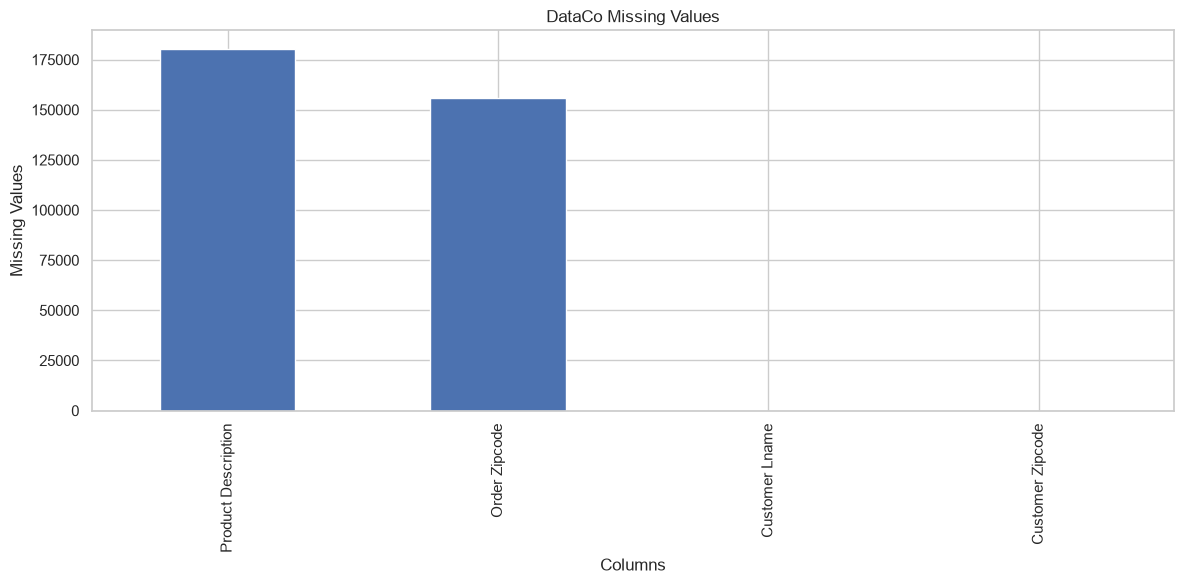

In [ ]:
##Visualize missing values
plt.figure(figsize=(12, 6))

missing = dataco.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)

missing.plot(kind="bar")

plt.title("DataCo Missing Values")
plt.xlabel("Columns")
plt.ylabel("Missing Values")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

In [ ]:
##check duplicate values
dataco_duplicates = dataco.duplicated().sum()
print("DataCo duplicates:", dataco_duplicates)

DataCo duplicates: 0


In [ ]:
dataco["Late_delivery_risk"].value_counts(dropna=False)


Late_delivery_risk
1    98977
0    81542
Name: count, dtype: int64

In [25]:
dataco["Late_delivery_risk"].value_counts(normalize=True)

Late_delivery_risk
1    0.548291
0    0.451709
Name: proportion, dtype: float64

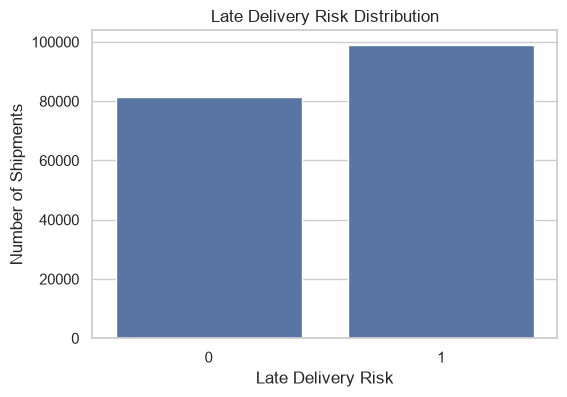

In [ ]:
plt.figure(figsize=(6, 4))

sns.countplot(
    data=dataco,
    x="Late_delivery_risk"
)

plt.title("Late Delivery Risk Distribution")
plt.xlabel("Late Delivery Risk")
plt.ylabel("Number of Shipments")

plt.show()




In [ ]:
##Check delivery status
dataco["Delivery Status"].value_counts(dropna=False)

Delivery Status
Late delivery        98977
Advance shipping     41592
Shipping on time     32196
Shipping canceled     7754
Name: count, dtype: int64

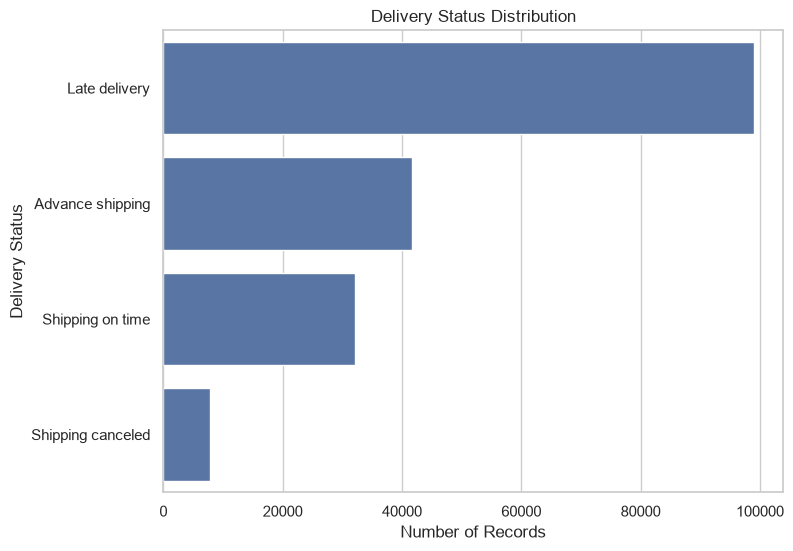

In [ ]:
plt.figure(figsize=(8,6))
sns.countplot(
    data=dataco,
    y="Delivery Status",
    order = dataco["Delivery Status"].value_counts().index
)

plt.title("Delivery Status Distribution")
plt.xlabel("Number of Records")
plt.ylabel("Delivery Status")
plt.show()

In [38]:
pd.crosstab(
    dataco["Delivery Status"],
    dataco["Late_delivery_risk"],
    normalize="index"
)

Late_delivery_risk,0,1
Delivery Status,,
Advance shipping,1.0,0.0
Late delivery,0.0,1.0
Shipping canceled,1.0,0.0
Shipping on time,1.0,0.0


In [39]:
# Shipping mode analysis

dataco["Shipping Mode"].value_counts()

Shipping Mode
Standard Class    107752
Second Class       35216
First Class        27814
Same Day            9737
Name: count, dtype: int64

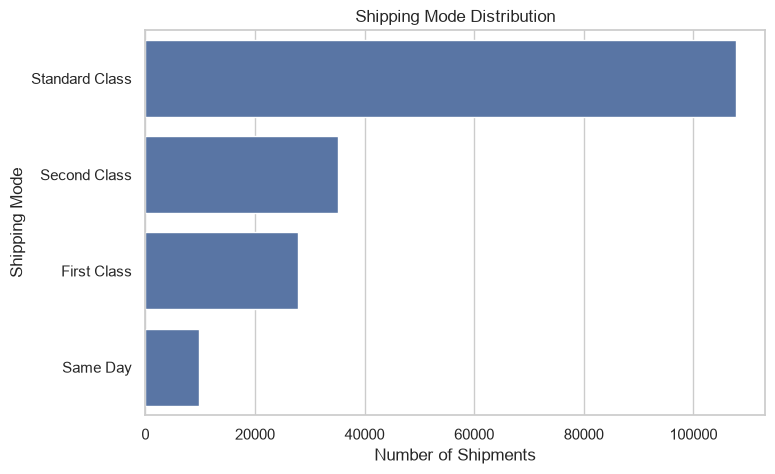

In [40]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=dataco,
    y="Shipping Mode",
    order=dataco["Shipping Mode"].value_counts().index
)

plt.title("Shipping Mode Distribution")
plt.xlabel("Number of Shipments")
plt.ylabel("Shipping Mode")

plt.show()

In [41]:
# Shipping mode vs delay
shipping_delay = pd.crosstab(
    dataco["Shipping Mode"],
    dataco["Late_delivery_risk"],
    normalize="index"
)

shipping_delay

Late_delivery_risk,0,1
Shipping Mode,,
First Class,0.046775,0.953225
Same Day,0.542570,0.457430
Second Class,0.233672,0.766328
Standard Class,0.619283,0.380717


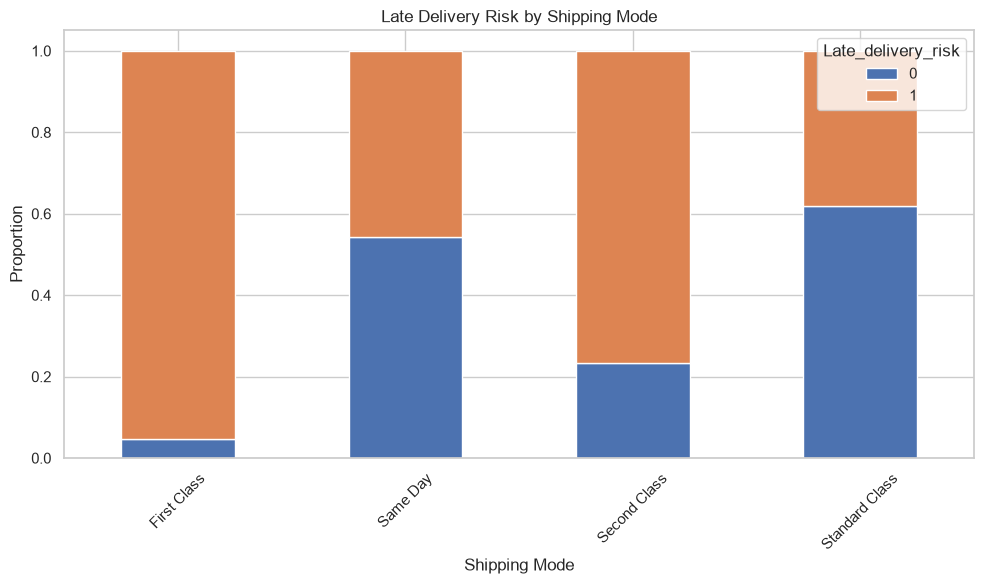

In [42]:
shipping_delay.plot(
    kind="bar",
    stacked=True,
    figsize=(10, 6)
)

plt.title("Late Delivery Risk by Shipping Mode")
plt.xlabel("Shipping Mode")
plt.ylabel("Proportion")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
# Region analysis


dataco["Order Region"].value_counts()

region_delay = (
    dataco.groupby("Order Region")["Late_delivery_risk"]
    .mean()
    .sort_values(ascending=False)
)

region_delay

Order Region
Central Africa     0.579606
South Asia         0.562670
East Africa        0.559395
Western Europe     0.558486
South of  USA      0.557726
Eastern Europe     0.556633
East of USA        0.556616
Southeast Asia     0.555299
Central Asia       0.553345
West Asia          0.552837
US Center          0.552404
Central America    0.547546
North Africa       0.545173
Southern Europe    0.543845
Eastern Asia       0.543269
South America      0.543087
Northern Europe    0.540441
Oceania            0.540205
West of USA        0.539597
Southern Africa    0.533276
Caribbean          0.530777
West Africa        0.528409
Canada             0.488008
Name: Late_delivery_risk, dtype: float64

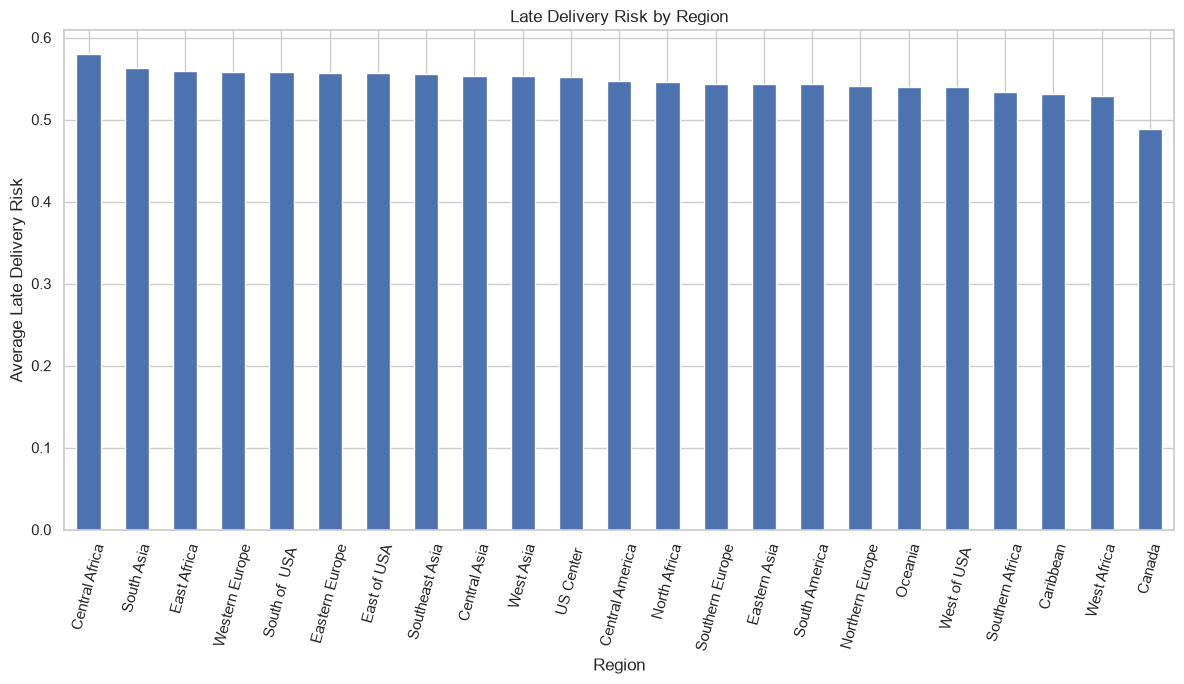

In [46]:
plt.figure(figsize=(12, 7))

region_delay.plot(kind="bar")

plt.title("Late Delivery Risk by Region")
plt.xlabel("Region")
plt.ylabel("Average Late Delivery Risk")

plt.xticks(rotation=75)
plt.tight_layout()
plt.show()

In [ ]:
# Market analysis
dataco["Market"].value_counts()

Market
LATAM           51594
Europe          50252
Pacific Asia    41260
USCA            25799
Africa          11614
Name: count, dtype: int64

In [48]:
market_delay = (
    dataco.groupby("Market")["Late_delivery_risk"]
    .mean()
    .sort_values(ascending=False)
)

market_delay

Market
Europe          0.552078
Pacific Asia    0.550460
USCA            0.548006
Africa          0.545893
LATAM           0.543552
Name: Late_delivery_risk, dtype: float64

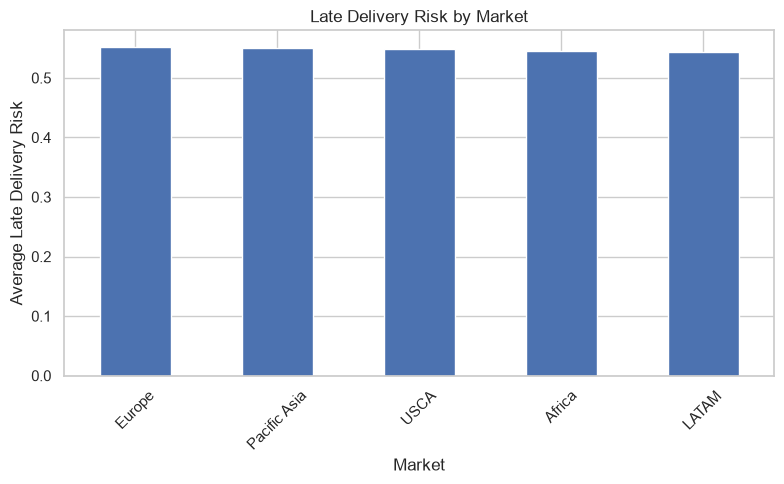

In [49]:
plt.figure(figsize=(8, 5))

market_delay.plot(kind="bar")

plt.title("Late Delivery Risk by Market")
plt.xlabel("Market")
plt.ylabel("Average Late Delivery Risk")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [50]:
# Numerical columns
numeric_dataco = dataco.select_dtypes(
    include=np.number
)

numeric_dataco.columns.tolist()

['Days for shipping (real)',
 'Days for shipment (scheduled)',
 'Benefit per order',
 'Sales per customer',
 'Late_delivery_risk',
 'Category Id',
 'Customer Id',
 'Customer Zipcode',
 'Department Id',
 'Latitude',
 'Longitude',
 'Order Customer Id',
 'Order Id',
 'Order Item Cardprod Id',
 'Order Item Discount',
 'Order Item Discount Rate',
 'Order Item Id',
 'Order Item Product Price',
 'Order Item Profit Ratio',
 'Order Item Quantity',
 'Sales',
 'Order Item Total',
 'Order Profit Per Order',
 'Order Zipcode',
 'Product Card Id',
 'Product Category Id',
 'Product Description',
 'Product Price',
 'Product Status']

In [ ]:
# Numerical distributions
dataco[
    [
        "Sales",
        "Order Item Quantity",
        "Order Item Discount",
        "Order Item Profit Ratio",
        "Days for shipping (real)",
        "Days for shipment (scheduled)"
    ]
].describe().T

,count,mean,std,min,25%,50%,75%,max
Sales,180519.0,203.772096,132.273077,9.99,119.980003,199.919998,299.950012,1999.98999
Order Item Quantity,180519.0,2.127638,1.453451,1.00,1.000000,1.000000,3.000000,5.00000
Order Item Discount,180519.0,20.664741,21.800901,0.00,5.400000,14.000000,29.990000,500.00000
Order Item Profit Ratio,180519.0,0.120647,0.466796,-2.75,0.080000,0.270000,0.360000,0.50000
Days for shipping (real),180519.0,3.497654,1.623722,0.00,2.000000,3.000000,5.000000,6.00000
Days for shipment (scheduled),180519.0,2.931847,1.374449,0.00,2.000000,4.000000,4.000000,4.00000


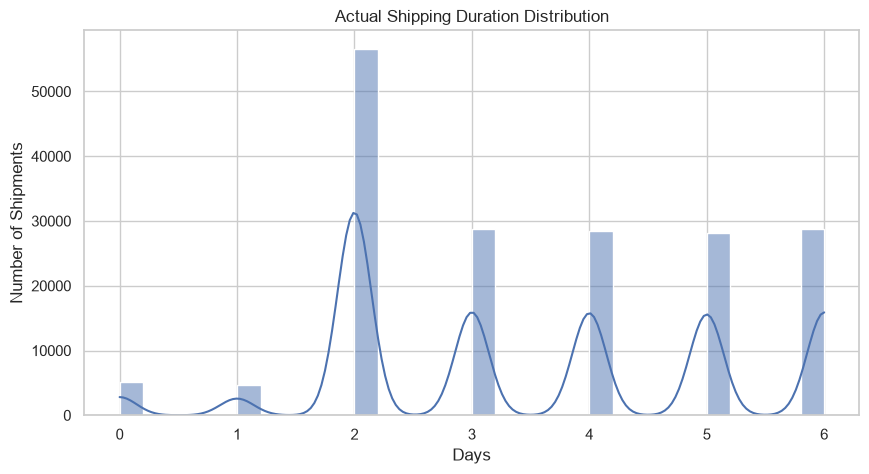

In [53]:
plt.figure(figsize=(10, 5))

sns.histplot(
    dataco["Days for shipping (real)"],
    bins=30,
    kde=True
)

plt.title("Actual Shipping Duration Distribution")
plt.xlabel("Days")
plt.ylabel("Number of Shipments")

plt.show()

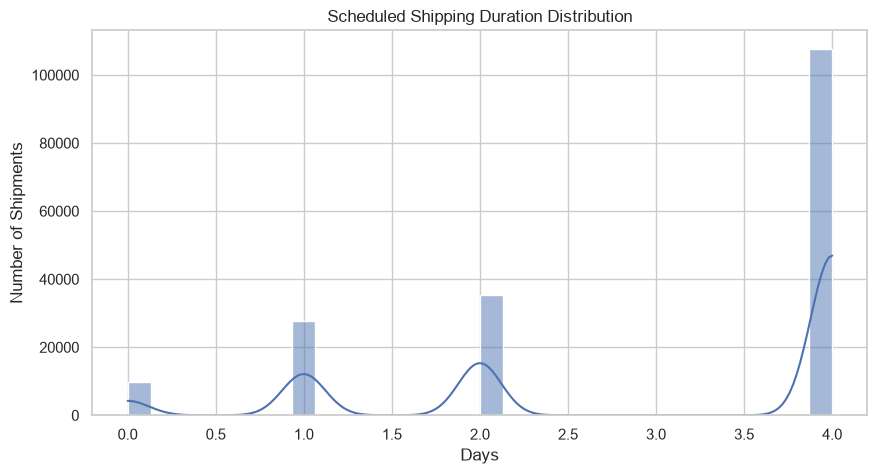

In [54]:
plt.figure(figsize=(10, 5))

sns.histplot(
    dataco["Days for shipment (scheduled)"],
    bins=30,
    kde=True
)

plt.title("Scheduled Shipping Duration Distribution")
plt.xlabel("Days")
plt.ylabel("Number of Shipments")

plt.show()

In [8]:
# Actual vs scheduled shipping
dataco["EDA_shipping_difference"] = (
    dataco["Days for shipping (real)"]
    - dataco["Days for shipment (scheduled)"]
)
dataco["EDA_shipping_difference"].describe()

count    180519.000000
mean          0.565807
std           1.490966
min          -2.000000
25%           0.000000
50%           1.000000
75%           1.000000
max           4.000000
Name: EDA_shipping_difference, dtype: float64

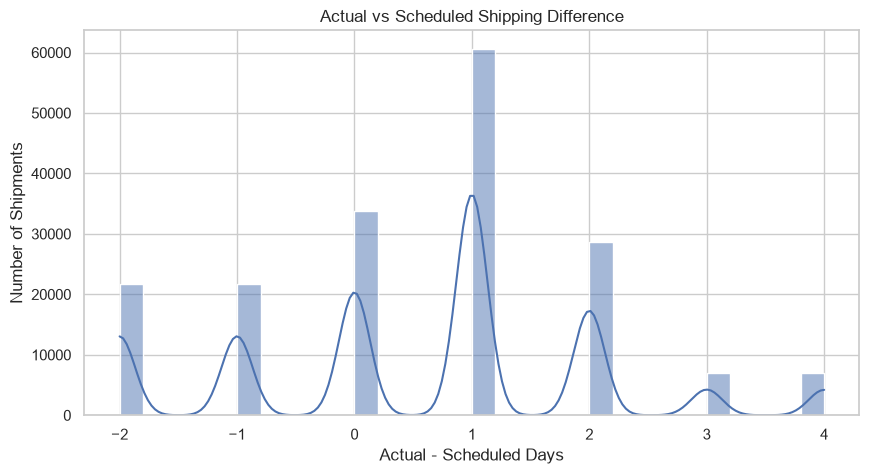

In [9]:
# Visualize shipping difference
plt.figure(figsize=(10, 5))

sns.histplot(
    dataco["EDA_shipping_difference"],
    bins=30,
    kde=True
)

plt.title("Actual vs Scheduled Shipping Difference")
plt.xlabel("Actual - Scheduled Days")
plt.ylabel("Number of Shipments")

plt.show()

In [10]:
dataco.groupby(
    "Late_delivery_risk"
)["EDA_shipping_difference"].describe()

,count,mean,std,min,25%,50%,75%,max
Late_delivery_risk,,,,,,,,
0,81542.0,-0.711584,0.999927,-2.0,-2.0,-1.0,0.0,4.0
1,98977.0,1.618184,0.882527,1.0,1.0,1.0,2.0,4.0


In [47]:
# Correlation analysis
dataco_numeric = dataco.select_dtypes(
    include=np.number
)

In [48]:
dataco_corr = dataco_numeric.corr()

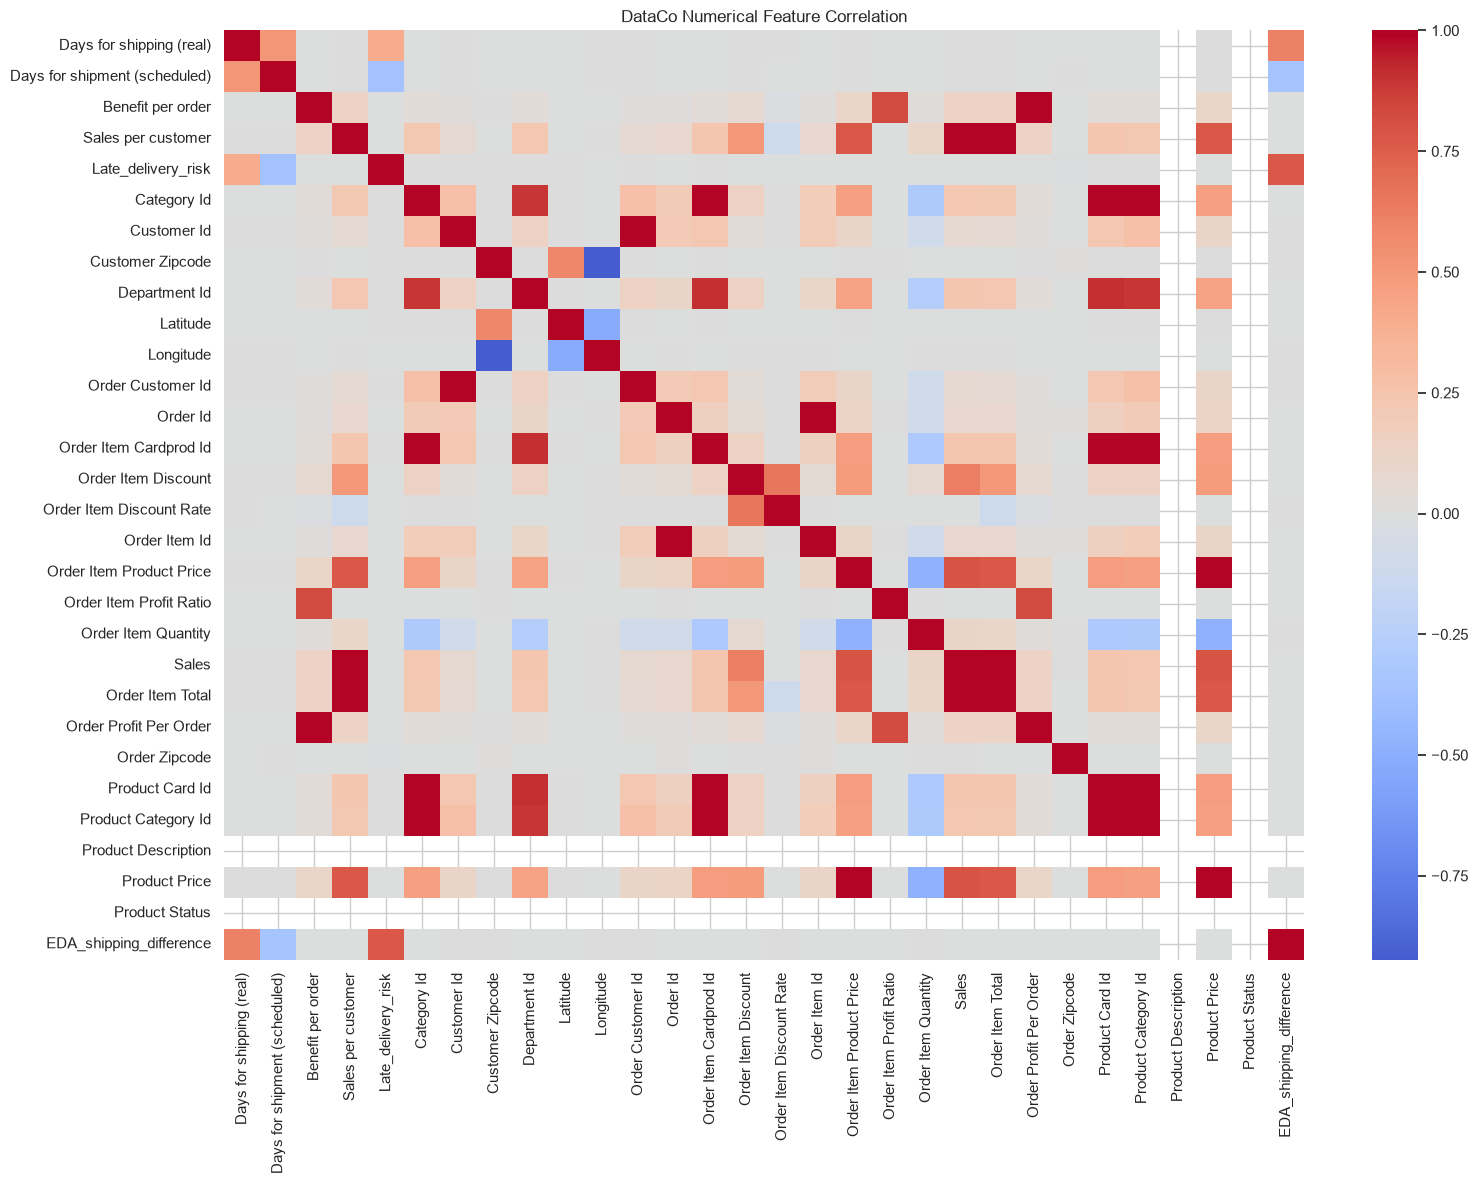

In [49]:
plt.figure(figsize=(16, 12))

sns.heatmap(
    dataco_corr,
    cmap="coolwarm",
    center=0
)

plt.title("DataCo Numerical Feature Correlation")

plt.tight_layout()
plt.show()

In [50]:
dataco_numeric.corr()["Late_delivery_risk"].sort_values(
    ascending=False
)

Late_delivery_risk               1.000000
EDA_shipping_difference          0.777644
Days for shipping (real)         0.401415
Customer Zipcode                 0.003148
Product Category Id              0.001752
Category Id                      0.001752
Product Card Id                  0.001490
Order Item Cardprod Id           0.001490
Order Customer Id                0.001484
Customer Id                      0.001484
Department Id                    0.001077
Latitude                         0.000679
Order Item Discount Rate         0.000404
Order Item Quantity             -0.000139
Order Item Discount             -0.000750
Order Id                        -0.001293
Order Item Id                   -0.001376
Longitude                       -0.001915
Product Price                   -0.002175
Order Item Product Price        -0.002175
Order Item Profit Ratio         -0.002316
Sales                           -0.003564
Benefit per order               -0.003727
Order Profit Per Order          -0

In [52]:
numeric_columns = [
    "Sales",
    "Order Item Quantity",
    "Order Item Discount",
    "Order Item Profit Ratio",
    "Days for shipping (real)",
    "Days for shipment (scheduled)"
]

In [53]:
dataco[numeric_columns].describe().T

,count,mean,std,min,25%,50%,75%,max
Sales,180519.0,203.772096,132.273077,9.99,119.980003,199.919998,299.950012,1999.98999
Order Item Quantity,180519.0,2.127638,1.453451,1.00,1.000000,1.000000,3.000000,5.00000
Order Item Discount,180519.0,20.664741,21.800901,0.00,5.400000,14.000000,29.990000,500.00000
Order Item Profit Ratio,180519.0,0.120647,0.466796,-2.75,0.080000,0.270000,0.360000,0.50000
Days for shipping (real),180519.0,3.497654,1.623722,0.00,2.000000,3.000000,5.000000,6.00000
Days for shipment (scheduled),180519.0,2.931847,1.374449,0.00,2.000000,4.000000,4.000000,4.00000


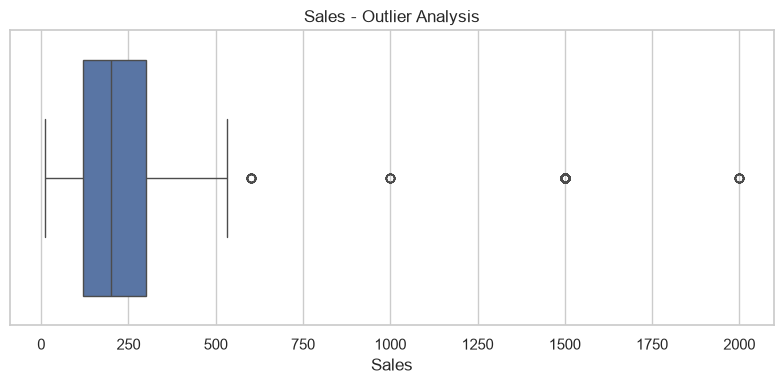

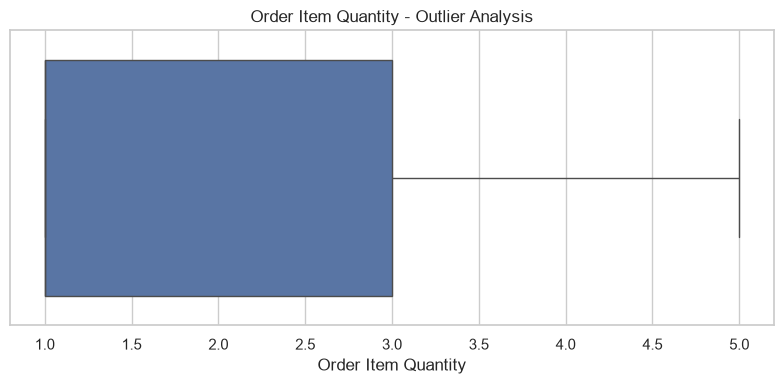

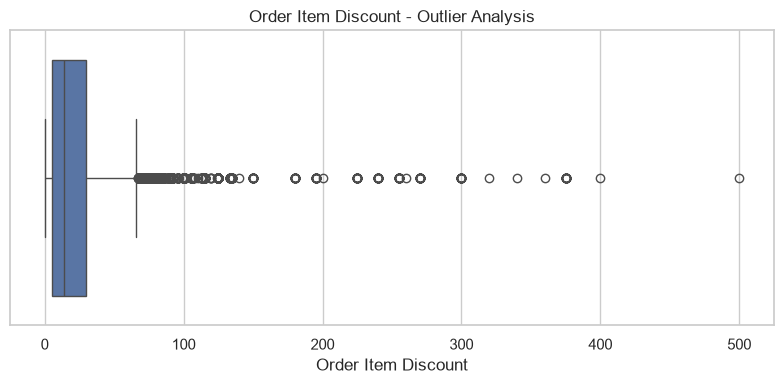

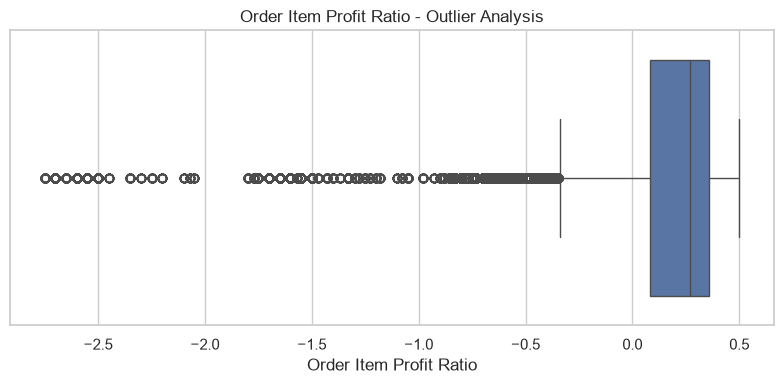

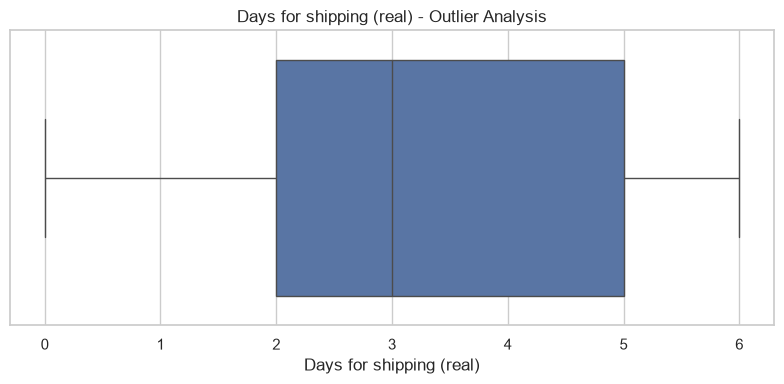

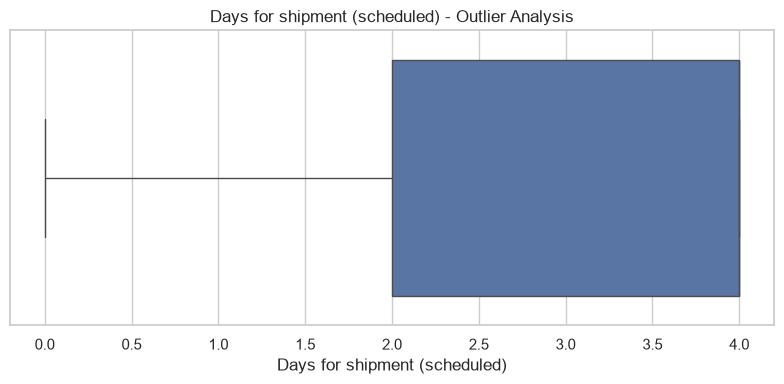

In [54]:
for column in numeric_columns:
    plt.figure(figsize=(8, 4))

    sns.boxplot(
        x=dataco[column]
    )

    plt.title(f"{column} - Outlier Analysis")
    plt.xlabel(column)

    plt.tight_layout()
    plt.show()

In [57]:
# Which shipping mode has the highest risk?
dataco.groupby(
    "Shipping Mode"
)["Late_delivery_risk"].mean().sort_values(
    ascending=False
)

Shipping Mode
First Class       0.953225
Second Class      0.766328
Same Day          0.457430
Standard Class    0.380717
Name: Late_delivery_risk, dtype: float64

In [58]:
# Which region has highest risk?
dataco.groupby(
    "Order Region"
)["Late_delivery_risk"].mean().sort_values(
    ascending=False
)

Order Region
Central Africa     0.579606
South Asia         0.562670
East Africa        0.559395
Western Europe     0.558486
South of  USA      0.557726
Eastern Europe     0.556633
East of USA        0.556616
Southeast Asia     0.555299
Central Asia       0.553345
West Asia          0.552837
US Center          0.552404
Central America    0.547546
North Africa       0.545173
Southern Europe    0.543845
Eastern Asia       0.543269
South America      0.543087
Northern Europe    0.540441
Oceania            0.540205
West of USA        0.539597
Southern Africa    0.533276
Caribbean          0.530777
West Africa        0.528409
Canada             0.488008
Name: Late_delivery_risk, dtype: float64

In [59]:
# Which market has highest risk?
dataco.groupby(
    "Market"
)["Late_delivery_risk"].mean().sort_values(
    ascending=False
)

Market
Europe          0.552078
Pacific Asia    0.550460
USCA            0.548006
Africa          0.545893
LATAM           0.543552
Name: Late_delivery_risk, dtype: float64

In [60]:
# Does longer scheduled shipping correlate with risk?
dataco.groupby(
    "Late_delivery_risk"
)["Days for shipment (scheduled)"].mean()

Late_delivery_risk
0    3.491146
1    2.471069
Name: Days for shipment (scheduled), dtype: float64

In [61]:
# Does actual shipping duration differ by risk?
dataco.groupby(
    "Late_delivery_risk"
)["Days for shipping (real)"].mean()

Late_delivery_risk
0    2.779561
1    4.089253
Name: Days for shipping (real), dtype: float64

this dataset is smart logistics 

In [12]:
smart_path = "../datasets/raw/smart_logistics/Smart_Logistics.csv"

smart = pd.read_csv(
    smart_path,
    encoding_errors="ignore"
)

smart.head()

,Timestamp,Asset_ID,Latitude,Longitude,Inventory_Level,Shipment_Status,Temperature,Humidity,Traffic_Status,Waiting_Time,User_Transaction_Amount,User_Purchase_Frequency,Logistics_Delay_Reason,Asset_Utilization,Demand_Forecast,Logistics_Delay
0,2024-03-20 00:11:14,Truck_7,-65.7383,11.2497,390,Delayed,27.0,67.8,Detour,38,320,4,NaN,60.1,285,1
1,2024-10-30 07:53:51,Truck_6,22.2748,-131.7086,491,In Transit,22.5,54.3,Heavy,16,439,7,Weather,80.9,174,1
2,2024-07-29 18:42:48,Truck_10,54.9232,79.5455,190,In Transit,25.2,62.2,Detour,34,355,3,NaN,99.2,260,0
3,2024-10-28 00:50:54,Truck_9,42.3900,-1.4788,330,Delivered,25.4,52.3,Heavy,37,227,5,Traffic,97.4,160,1
4,2024-09-27 15:52:58,Truck_7,-65.8477,47.9468,480,Delayed,20.5,57.2,Clear,56,197,6,NaN,71.6,270,1


In [15]:
print("Smart Logistics shape:", smart.shape)

Smart Logistics shape: (1000, 16)


In [16]:
smart.info

<bound method DataFrame.info of                Timestamp  Asset_ID  Latitude  Longitude  Inventory_Level  \
0    2024-03-20 00:11:14   Truck_7  -65.7383    11.2497              390   
1    2024-10-30 07:53:51   Truck_6   22.2748  -131.7086              491   
2    2024-07-29 18:42:48  Truck_10   54.9232    79.5455              190   
3    2024-10-28 00:50:54   Truck_9   42.3900    -1.4788              330   
4    2024-09-27 15:52:58   Truck_7  -65.8477    47.9468              480   
..                   ...       ...       ...        ...              ...   
995  2024-07-22 16:30:00   Truck_6   89.8701    73.6867              264   
996  2024-04-30 04:58:58   Truck_5  -10.4792  -177.1239              479   
997  2024-10-27 22:09:13   Truck_2  -71.0609    75.3714              347   
998  2024-04-18 23:06:56   Truck_2  -76.7910    18.3631              276   
999  2024-09-18 19:39:24   Truck_8   59.8356  -114.4198              157   

    Shipment_Status  Temperature  Humidity Traffic_Stat

In [46]:
smart.describe(include="object").T

C:\Users\anujk\AppData\Local\Temp\ipykernel_12940\1602051477.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  smart.describe(include="object").T


,count,unique,top,freq
Timestamp,1000,1000,2024-03-20 00:11:14,1
Asset_ID,1000,10,Truck_8,109
Shipment_Status,1000,3,Delayed,350
Traffic_Status,1000,3,Detour,345
Logistics_Delay_Reason,737,3,Weather,267


In [33]:
smart.head()

,Timestamp,Asset_ID,Latitude,Longitude,Inventory_Level,Shipment_Status,Temperature,Humidity,Traffic_Status,Waiting_Time,User_Transaction_Amount,User_Purchase_Frequency,Logistics_Delay_Reason,Asset_Utilization,Demand_Forecast,Logistics_Delay
0,2024-03-20 00:11:14,Truck_7,-65.7383,11.2497,390,Delayed,27.0,67.8,Detour,38,320,4,NaN,60.1,285,1
1,2024-10-30 07:53:51,Truck_6,22.2748,-131.7086,491,In Transit,22.5,54.3,Heavy,16,439,7,Weather,80.9,174,1
2,2024-07-29 18:42:48,Truck_10,54.9232,79.5455,190,In Transit,25.2,62.2,Detour,34,355,3,NaN,99.2,260,0
3,2024-10-28 00:50:54,Truck_9,42.3900,-1.4788,330,Delivered,25.4,52.3,Heavy,37,227,5,Traffic,97.4,160,1
4,2024-09-27 15:52:58,Truck_7,-65.8477,47.9468,480,Delayed,20.5,57.2,Clear,56,197,6,NaN,71.6,270,1


In [34]:
smart.tail()

,Timestamp,Asset_ID,Latitude,Longitude,Inventory_Level,Shipment_Status,Temperature,Humidity,Traffic_Status,Waiting_Time,User_Transaction_Amount,User_Purchase_Frequency,Logistics_Delay_Reason,Asset_Utilization,Demand_Forecast,Logistics_Delay
995,2024-07-22 16:30:00,Truck_6,89.8701,73.6867,264,Delivered,26.9,70.0,Heavy,32,188,1,Weather,79.2,213,1
996,2024-04-30 04:58:58,Truck_5,-10.4792,-177.1239,479,Delivered,23.7,77.9,Detour,56,276,7,Weather,83.7,272,0
997,2024-10-27 22:09:13,Truck_2,-71.0609,75.3714,347,In Transit,21.0,63.1,Detour,35,382,5,NaN,74.8,275,0
998,2024-04-18 23:06:56,Truck_2,-76.7910,18.3631,276,Delivered,18.0,64.3,Heavy,10,361,5,NaN,88.6,242,1
999,2024-09-18 19:39:24,Truck_8,59.8356,-114.4198,157,Delayed,18.7,73.6,Clear,55,323,9,Mechanical Failure,81.3,141,1


In [14]:
smart.columns.tolist()

['Timestamp',
 'Asset_ID',
 'Latitude',
 'Longitude',
 'Inventory_Level',
 'Shipment_Status',
 'Temperature',
 'Humidity',
 'Traffic_Status',
 'Waiting_Time',
 'User_Transaction_Amount',
 'User_Purchase_Frequency',
 'Logistics_Delay_Reason',
 'Asset_Utilization',
 'Demand_Forecast',
 'Logistics_Delay']

In [15]:
smart.isnull().sum().sort_values(ascending=False)

Logistics_Delay_Reason     263
Timestamp                    0
Latitude                     0
Asset_ID                     0
Inventory_Level              0
Shipment_Status              0
Temperature                  0
Longitude                    0
Humidity                     0
Traffic_Status               0
User_Transaction_Amount      0
Waiting_Time                 0
User_Purchase_Frequency      0
Asset_Utilization            0
Demand_Forecast              0
Logistics_Delay              0
dtype: int64

In [16]:
smart.duplicated().sum()

np.int64(0)

In [18]:
smart.isnull().sum().sort_values(ascending=False)

Logistics_Delay_Reason     263
Timestamp                    0
Latitude                     0
Asset_ID                     0
Inventory_Level              0
Shipment_Status              0
Temperature                  0
Longitude                    0
Humidity                     0
Traffic_Status               0
User_Transaction_Amount      0
Waiting_Time                 0
User_Purchase_Frequency      0
Asset_Utilization            0
Demand_Forecast              0
Logistics_Delay              0
dtype: int64

In [22]:
smart["Shipment_Status"].value_counts(dropna=False)

Shipment_Status
Delayed       350
Delivered     338
In Transit    312
Name: count, dtype: int64

In [23]:
smart["Traffic_Status"].value_counts(dropna=False)

Traffic_Status
Detour    345
Clear     328
Heavy     327
Name: count, dtype: int64

In [24]:
smart["Logistics_Delay"].value_counts(dropna=False)

Logistics_Delay
1    566
0    434
Name: count, dtype: int64

In [38]:
smart.sample(10, random_state=42)

,Timestamp,Asset_ID,Latitude,Longitude,Inventory_Level,Shipment_Status,Temperature,Humidity,Traffic_Status,Waiting_Time,User_Transaction_Amount,User_Purchase_Frequency,Logistics_Delay_Reason,Asset_Utilization,Demand_Forecast,Logistics_Delay
521,2024-08-11 04:43:30,Truck_9,5.0095,-113.8279,145,Delayed,18.2,62.2,Heavy,56,430,5,Traffic,86.7,260,1
737,2024-02-05 00:48:18,Truck_2,20.3388,-109.3313,378,In Transit,21.0,60.8,Heavy,30,318,3,Weather,84.8,181,1
740,2024-01-09 23:18:24,Truck_7,1.3295,83.6357,483,Delayed,28.6,72.4,Clear,51,243,1,Traffic,73.7,167,1
660,2024-03-13 18:47:10,Truck_9,57.9277,-106.3278,330,In Transit,29.5,68.5,Clear,14,358,1,Mechanical Failure,70.0,283,0
411,2024-02-11 10:31:50,Truck_10,-61.8490,-123.7835,445,Delivered,19.8,54.1,Clear,39,375,2,Weather,88.3,247,0
678,2024-11-20 15:27:33,Truck_2,-78.4902,-101.3255,142,Delayed,24.0,51.6,Clear,40,160,7,NaN,70.0,276,1
626,2024-06-22 06:59:47,Truck_8,-61.1518,140.8152,407,In Transit,19.9,50.7,Heavy,55,421,1,Mechanical Failure,87.2,237,1
513,2024-12-14 00:45:10,Truck_6,-57.3005,-23.6888,403,In Transit,29.6,63.0,Clear,12,197,4,NaN,83.8,228,0
859,2024-06-17 14:27:56,Truck_6,-71.8307,-53.6072,274,Delivered,21.5,74.0,Heavy,23,448,5,Mechanical Failure,74.7,200,1
136,2024-06-07 06:45:59,Truck_3,-6.2311,173.6264,402,Delivered,27.0,74.2,Heavy,17,155,10,Traffic,73.4,281,1


In [40]:
smart_columns = pd.DataFrame({
    "column": smart.columns,
    "dtype": smart.dtypes.astype(str).values
})

smart_columns

,column,dtype
0,Timestamp,str
1,Asset_ID,str
2,Latitude,float64
3,Longitude,float64
4,Inventory_Level,int64
5,Shipment_Status,str
6,Temperature,float64
7,Humidity,float64
8,Traffic_Status,str
9,Waiting_Time,int64


In [42]:
smart.dtypes.value_counts()

int64      6
str        5
float64    5
Name: count, dtype: int64

In [43]:
smart.info(memory_usage="deep")

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 16 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Timestamp                1000 non-null   str    
 1   Asset_ID                 1000 non-null   str    
 2   Latitude                 1000 non-null   float64
 3   Longitude                1000 non-null   float64
 4   Inventory_Level          1000 non-null   int64  
 5   Shipment_Status          1000 non-null   str    
 6   Temperature              1000 non-null   float64
 7   Humidity                 1000 non-null   float64
 8   Traffic_Status           1000 non-null   str    
 9   Waiting_Time             1000 non-null   int64  
 10  User_Transaction_Amount  1000 non-null   int64  
 11  User_Purchase_Frequency  1000 non-null   int64  
 12  Logistics_Delay_Reason   737 non-null    str    
 13  Asset_Utilization        1000 non-null   float64
 14  Demand_Forecast          1000 non-nu

In [17]:
for column in smart.select_dtypes(include="object").columns:
    print(f"\n{'='*60}")
    print(column)

    print(f"Unique values: {smart[column].nunique()}")
    print(smart[column].value_counts(dropna=False).head(10))


Timestamp
Unique values: 1000
Timestamp
2024-03-20 00:11:14    1
2024-10-30 07:53:51    1
2024-07-29 18:42:48    1
2024-10-28 00:50:54    1
2024-09-27 15:52:58    1
2024-09-17 06:02:15    1
2024-02-05 08:38:56    1
2024-09-28 09:08:23    1
2024-01-18 08:27:04    1
2024-11-09 00:48:26    1
Name: count, dtype: int64

Asset_ID
Unique values: 10
Asset_ID
Truck_8     109
Truck_4     107
Truck_10    105
Truck_2     105
Truck_6     103
Truck_7     102
Truck_9      94
Truck_3      93
Truck_5      93
Truck_1      89
Name: count, dtype: int64

Shipment_Status
Unique values: 3
Shipment_Status
Delayed       350
Delivered     338
In Transit    312
Name: count, dtype: int64

Traffic_Status
Unique values: 3
Traffic_Status
Detour    345
Clear     328
Heavy     327
Name: count, dtype: int64

Logistics_Delay_Reason
Unique values: 3
Logistics_Delay_Reason
Weather               267
NaN                   263
Traffic               236
Mechanical Failure    234
Name: count, dtype: int64


C:\Users\anujk\AppData\Local\Temp\ipykernel_9492\2898468823.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for column in smart.select_dtypes(include="object").columns:


In [18]:
##Missing value analysis
smart_missing = pd.DataFrame({
    "missing_count": smart.isnull().sum(),
    "missing_percentage":(
        smart.isnull().sum() / len(smart)*100
    )

}).sort_values(
    "missing_percentage",
    ascending = False

)
smart_missing

,missing_count,missing_percentage
Logistics_Delay_Reason,263,26.3
Timestamp,0,0.0
Latitude,0,0.0
Asset_ID,0,0.0
Inventory_Level,0,0.0
Shipment_Status,0,0.0
Temperature,0,0.0
Longitude,0,0.0
Humidity,0,0.0
Traffic_Status,0,0.0


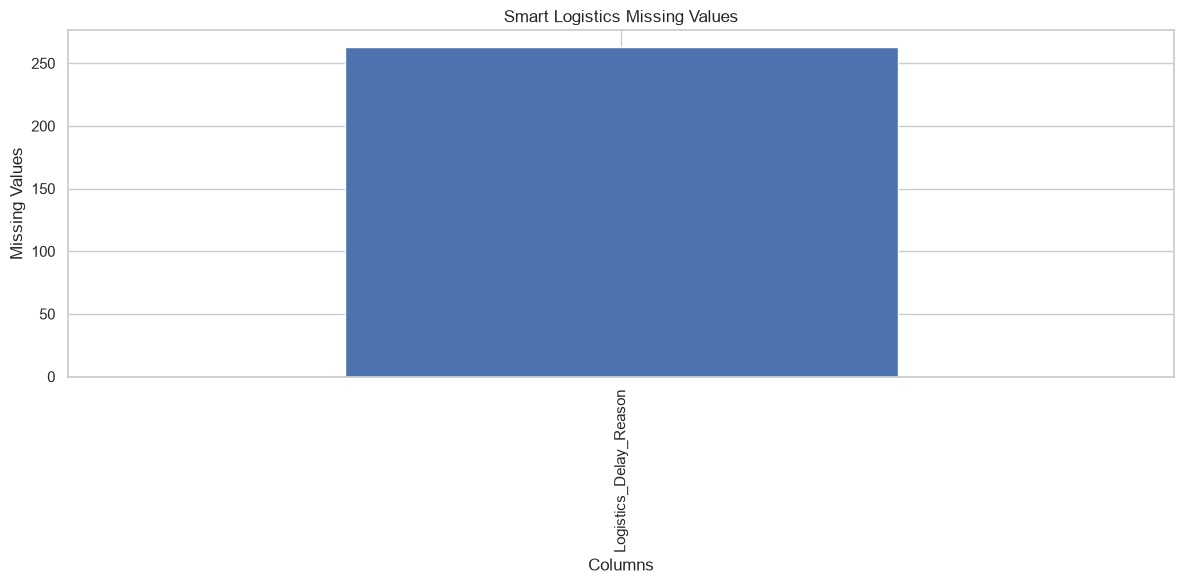

In [ ]:
##Visualize missing values
plt.figure(figsize=(12, 6))

missing = smart.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)

missing.plot(kind="bar")

plt.title("Smart Logistics Missing Values")
plt.xlabel("Columns")
plt.ylabel("Missing Values")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

In [22]:
smart_duplicates = smart.duplicated().sum()
print("Smart Logistics duplicates:", smart_duplicates)

Smart Logistics duplicates: 0


In [ ]:
# Numerical columns
numeric_smart = smart.select_dtypes(
    include=np.number
)

numeric_smart.columns.tolist()

['Latitude',
 'Longitude',
 'Inventory_Level',
 'Temperature',
 'Humidity',
 'Waiting_Time',
 'User_Transaction_Amount',
 'User_Purchase_Frequency',
 'Asset_Utilization',
 'Demand_Forecast',
 'Logistics_Delay']

In [ ]:
# Smart Logistics target
smart["Logistics_Delay"].value_counts(dropna=False)
smart["Logistics_Delay"].value_counts(normalize=True)

Logistics_Delay
1    0.566
0    0.434
Name: proportion, dtype: float64

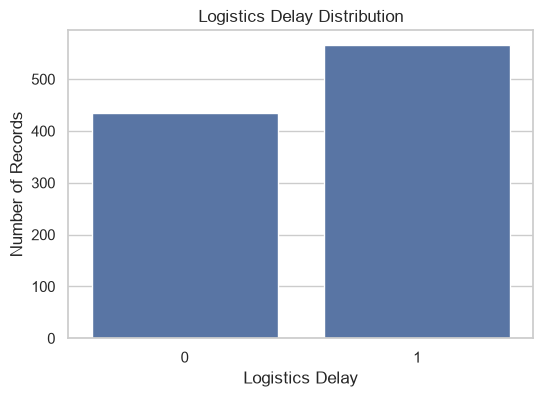

In [14]:
plt.figure(figsize=(6, 4))
sns.countplot(
    data=smart,
    x="Logistics_Delay"
)
plt.title("Logistics Delay Distribution")
plt.xlabel("Logistics Delay")
plt.ylabel("Number of Records")
plt.show()

In [15]:
# Smart Logistics shipment status
smart["Shipment_Status"].value_counts(dropna=False)


Shipment_Status
Delayed       350
Delivered     338
In Transit    312
Name: count, dtype: int64

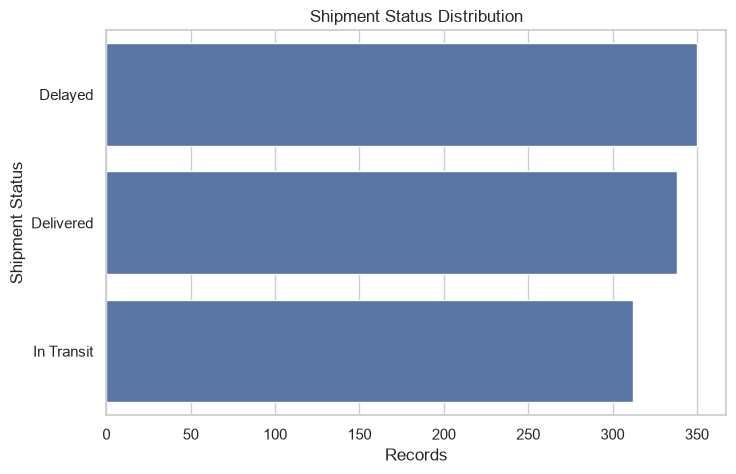

In [16]:
#Vizualize this shipment status
plt.figure(figsize=(8, 5))

sns.countplot(
    data=smart,
    y="Shipment_Status",
    order=smart["Shipment_Status"].value_counts().index
)

plt.title("Shipment Status Distribution")
plt.xlabel("Records")
plt.ylabel("Shipment Status")

plt.show()

In [17]:
##Trafic Analysis
smart["Traffic_Status"].value_counts(dropna=False)


Traffic_Status
Detour    345
Clear     328
Heavy     327
Name: count, dtype: int64

In [18]:
traffic_delay = (
    smart.groupby("Traffic_Status")["Logistics_Delay"]
    .mean()
    .sort_values(ascending=False)
)

traffic_delay

Traffic_Status
Heavy     1.00000
Detour    0.35942
Clear     0.35061
Name: Logistics_Delay, dtype: float64

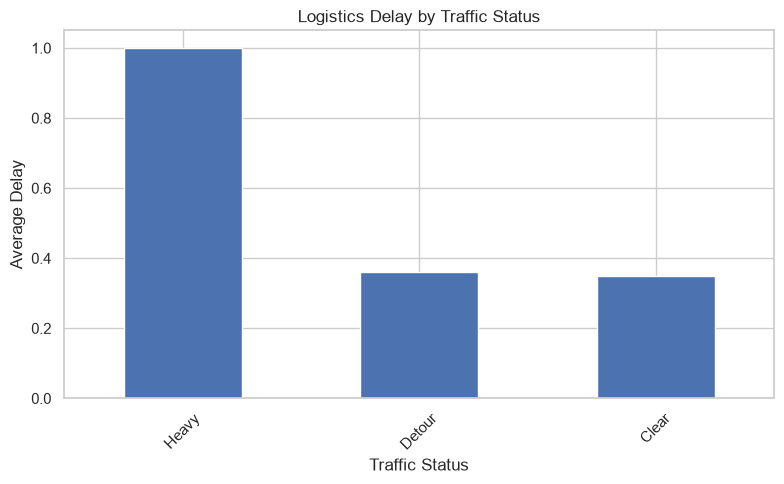

In [19]:
plt.figure(figsize=(8, 5))

traffic_delay.plot(kind="bar")

plt.title("Logistics Delay by Traffic Status")
plt.xlabel("Traffic Status")
plt.ylabel("Average Delay")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [20]:
#waiting time analyssis
smart["Waiting_Time"].describe()


count    1000.000000
mean       35.062000
std        14.477768
min        10.000000
25%        23.000000
50%        35.000000
75%        49.000000
max        60.000000
Name: Waiting_Time, dtype: float64

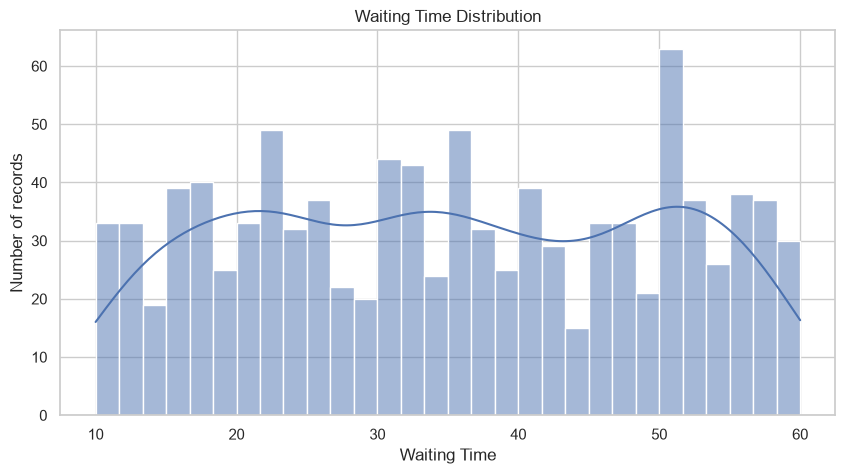

In [21]:
plt.figure(figsize=(10,5))
sns.histplot(
    smart["Waiting_Time"],
    bins=30,
    kde=True
)
plt.title("Waiting Time Distribution")
plt.xlabel("Waiting Time")
plt.ylabel("Number of records")
plt.show()

In [22]:
smart.groupby(
    "Logistics_Delay"
)["Waiting_Time"].describe()

,count,mean,std,min,25%,50%,75%,max
Logistics_Delay,,,,,,,,
0,434.0,36.103687,14.186024,10.0,24.0,36.0,49.0,60.0
1,566.0,34.263251,14.659907,10.0,22.0,34.0,48.0,60.0


In [23]:
# Temperature analysis
smart["Temperature"].describe()

count    1000.000000
mean       23.893900
std         3.322178
min        18.000000
25%        21.200000
50%        23.800000
75%        26.600000
max        30.000000
Name: Temperature, dtype: float64

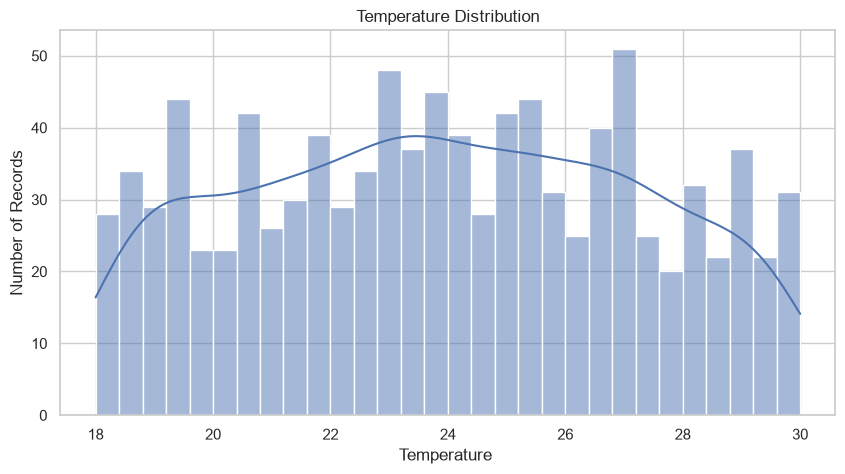

In [24]:
plt.figure(figsize=(10, 5))
sns.histplot(
    smart["Temperature"],
    bins=30,
    kde=True
)

plt.title("Temperature Distribution")
plt.xlabel("Temperature ")
plt.ylabel("Number of Records")
plt.show()

In [25]:
smart.groupby(
    "Logistics_Delay"
)["Temperature"].mean()

Logistics_Delay
0    24.038249
1    23.783216
Name: Temperature, dtype: float64

In [ ]:
# Humidity analysis
smart["Humidity"].describe()



count    1000.000000
mean       65.042200
std         8.753765
min        50.000000
25%        57.200000
50%        65.200000
75%        72.400000
max        80.000000
Name: Humidity, dtype: float64

In [28]:
smart.groupby(
    "Logistics_Delay"
)["Humidity"].mean()

Logistics_Delay
0    65.047235
1    65.038339
Name: Humidity, dtype: float64

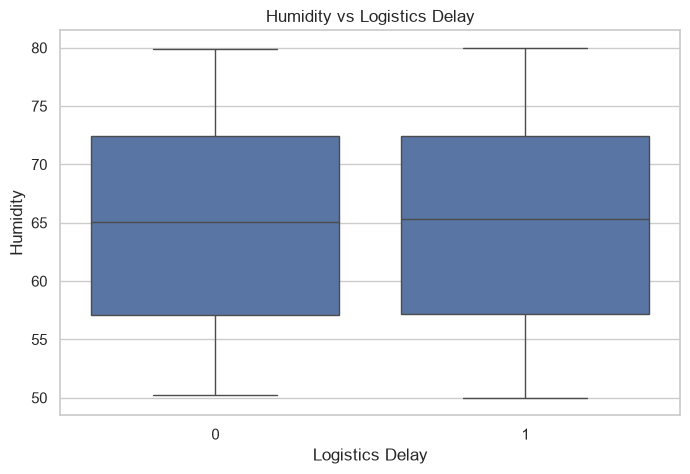

In [29]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=smart,
    x="Logistics_Delay",
    y="Humidity"
)

plt.title("Humidity vs Logistics Delay")
plt.xlabel("Logistics Delay")
plt.ylabel("Humidity")

plt.show()

In [30]:
# Asset utilization
smart["Asset_Utilization"].describe()


count    1000.000000
mean       79.599100
std        11.631153
min        60.000000
25%        69.475000
50%        79.250000
75%        89.425000
max       100.000000
Name: Asset_Utilization, dtype: float64

In [31]:
smart.groupby(
    "Logistics_Delay"
)["Asset_Utilization"].mean()

Logistics_Delay
0    79.640783
1    79.567138
Name: Asset_Utilization, dtype: float64

In [32]:
# Delay reasons
smart["Logistics_Delay_Reason"].value_counts(dropna=False)

Logistics_Delay_Reason
Weather               267
NaN                   263
Traffic               236
Mechanical Failure    234
Name: count, dtype: int64

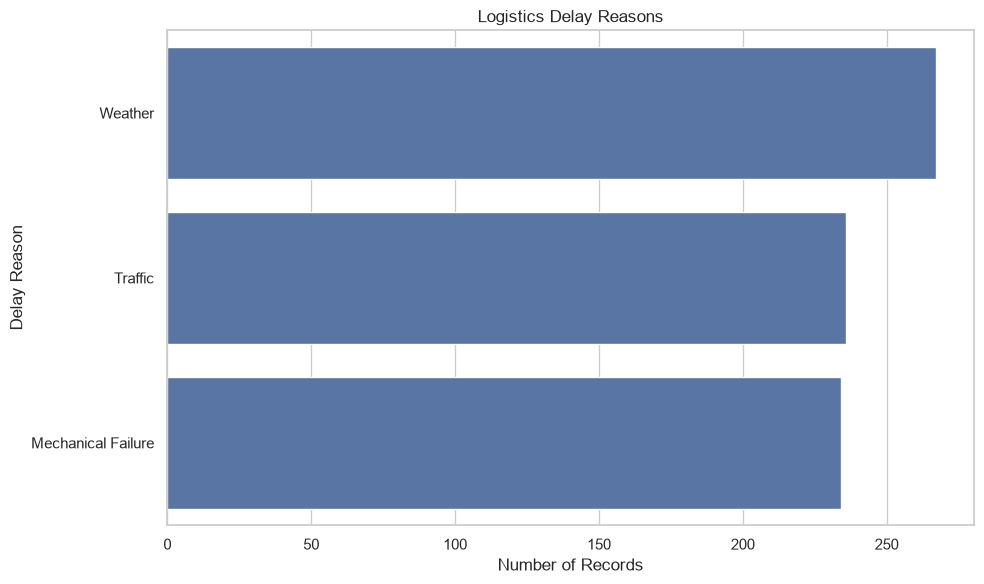

In [ ]:
plt.figure(figsize=(10, 6))

sns.countplot(
    data=smart,
    y="Logistics_Delay_Reason",
    order=smart["Logistics_Delay_Reason"].value_counts().index
)

plt.title("Logistics Delay Reasons")
plt.xlabel("Number of Records")
plt.ylabel("Delay Reason")

plt.tight_layout()
plt.show()

# This is especially useful for our future:

# AI Explanation

# and:

# Recommendation Engine

# because eventually CargoPulse should be able to explain:

# Why is this shipment risky?

In [34]:
# Timestamp analysis
smart["Timestamp"].head()


0    2024-03-20 00:11:14
1    2024-10-30 07:53:51
2    2024-07-29 18:42:48
3    2024-10-28 00:50:54
4    2024-09-27 15:52:58
Name: Timestamp, dtype: str

In [37]:
# smart["Timestamp"].dtype
smart["EDA_Timestamp"] = pd.to_datetime(
    smart["Timestamp"],
    errors="coerce"
)
smart["EDA_Timestamp"].describe()

count                          1000
mean     2024-06-30 23:15:56.539000
min             2024-01-01 11:37:57
25%      2024-03-27 01:27:56.500000
50%      2024-07-01 03:30:16.500000
75%      2024-10-02 13:30:34.500000
max             2024-12-30 20:21:58
Name: EDA_Timestamp, dtype: object

In [38]:
# Time coverage
print("Start:", smart["EDA_Timestamp"].min())
print("End:", smart["EDA_Timestamp"].max())

Start: 2024-01-01 11:37:57
End: 2024-12-30 20:21:58


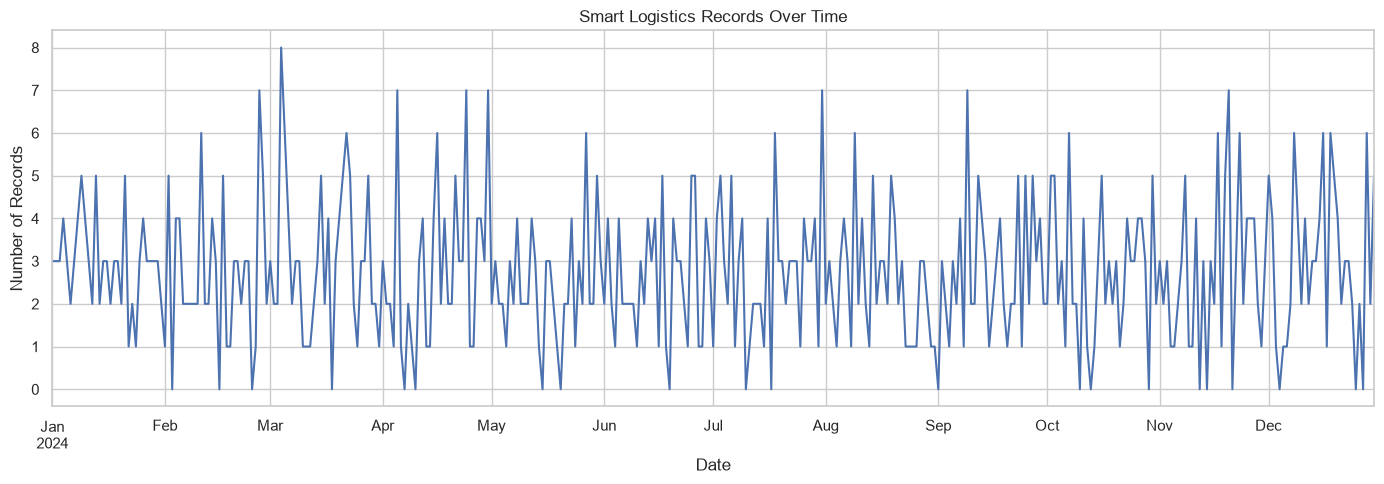

In [40]:
# Records over time
records_by_date = (
    smart.set_index("EDA_Timestamp")
    .resample("D")
    .size()
)
plt.figure(figsize=(14, 5))

records_by_date.plot()

plt.title("Smart Logistics Records Over Time")
plt.xlabel("Date")
plt.ylabel("Number of Records")

plt.tight_layout()
plt.show()

In [41]:
# Records per shipment/asset
smart["Asset_ID"].nunique()
smart["Asset_ID"].value_counts().describe()

count     10.000000
mean     100.000000
std        7.055337
min       89.000000
25%       93.250000
50%      102.500000
75%      105.000000
max      109.000000
Name: count, dtype: float64

In [42]:
# GPS analysis
smart[["Latitude", "Longitude"]].describe()



,Latitude,Longitude
count,1000.000000,1000.000000
mean,-1.360093,0.837049
std,51.997183,104.843618
min,-89.791500,-179.820200
25%,-46.167975,-88.448075
50%,-4.503150,0.678300
75%,44.502800,88.156450
max,89.870100,179.923700


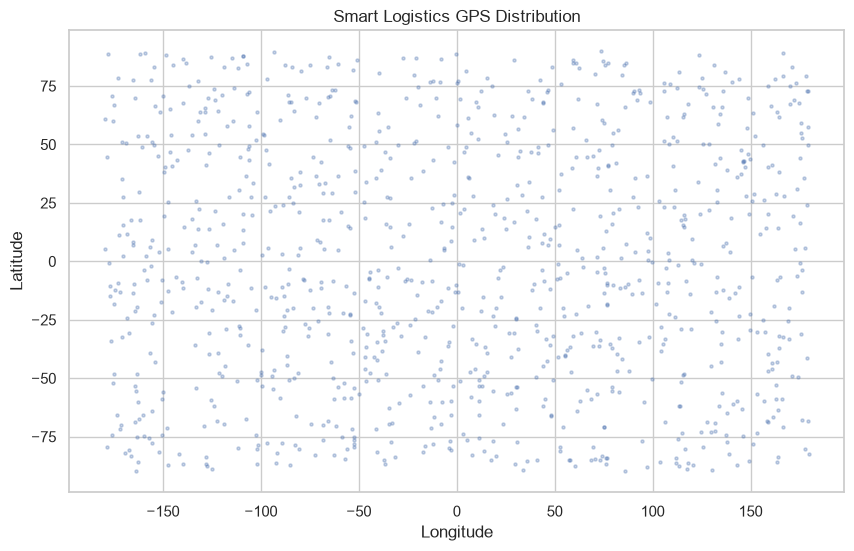

In [43]:
plt.figure(figsize=(10, 6))

plt.scatter(
    smart["Longitude"],
    smart["Latitude"],
    s=5,
    alpha=0.3
)

plt.title("Smart Logistics GPS Distribution")
plt.xlabel("Longitude")
plt.ylabel("Latitude")

plt.show()

In [44]:
# Correlation analysis
smart_numeric = smart.select_dtypes(
    include=np.number
)

In [45]:
smart_corr = smart_numeric.corr()

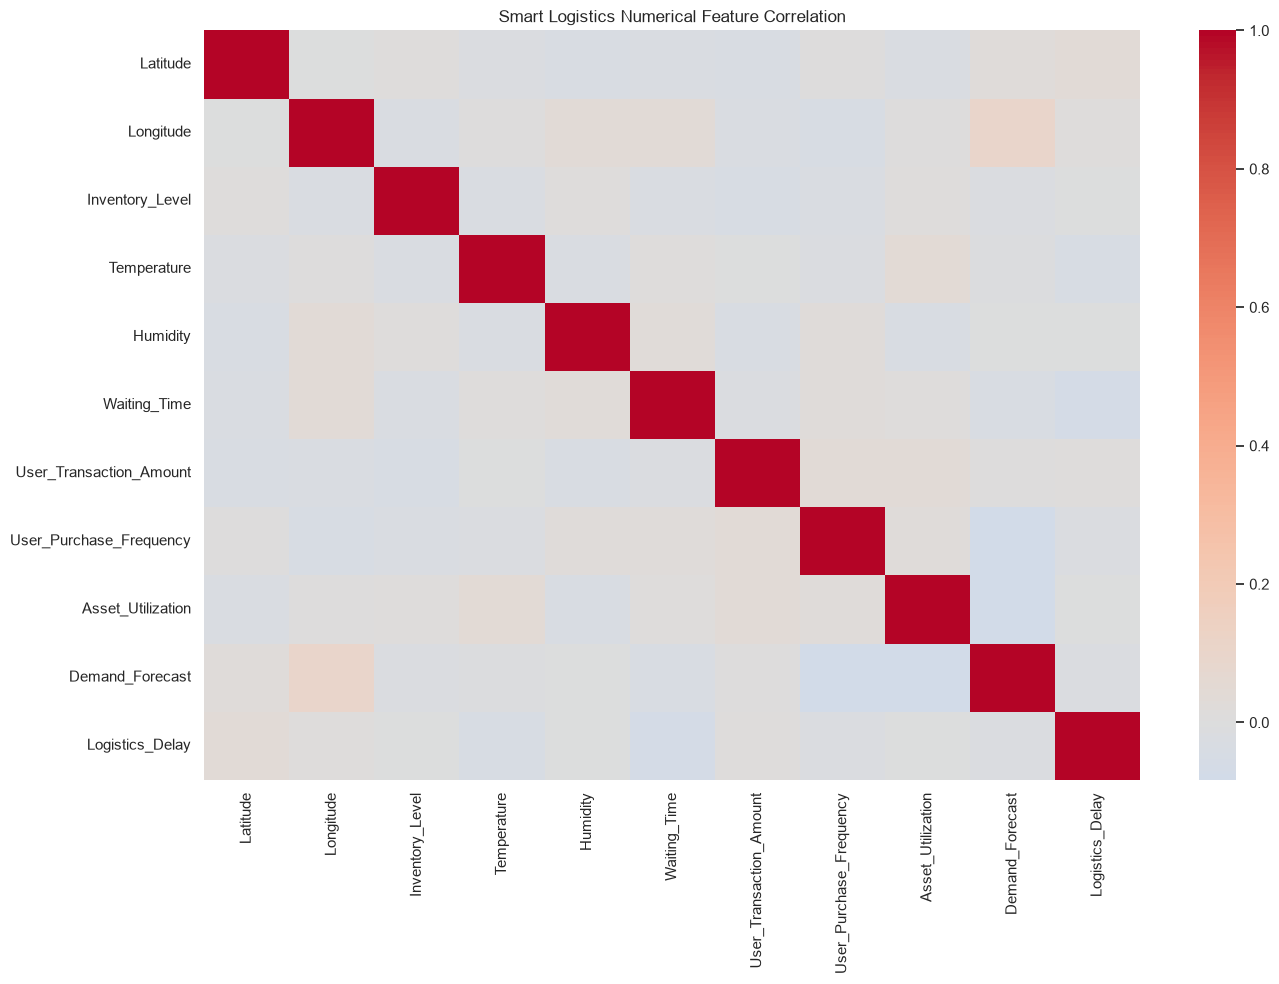

In [46]:
plt.figure(figsize=(14, 10))

sns.heatmap(
    smart_corr,
    cmap="coolwarm",
    center=0
)

plt.title("Smart Logistics Numerical Feature Correlation")

plt.tight_layout()
plt.show()

In [51]:
smart_numeric.corr()["Logistics_Delay"].sort_values(
    ascending=False
)

Logistics_Delay            1.000000
Latitude                   0.039634
User_Transaction_Amount    0.013605
Longitude                  0.011796
Humidity                  -0.000504
Asset_Utilization         -0.003140
Inventory_Level           -0.003340
User_Purchase_Frequency   -0.017439
Demand_Forecast           -0.018621
Temperature               -0.038067
Waiting_Time              -0.063036
Name: Logistics_Delay, dtype: float64

In [55]:
# Smart Logistics outliers
smart_numeric_columns = [
    "Temperature",
    "Humidity",
    "Waiting_Time",
    "Asset_Utilization",
    "Latitude",
    "Longitude"
]

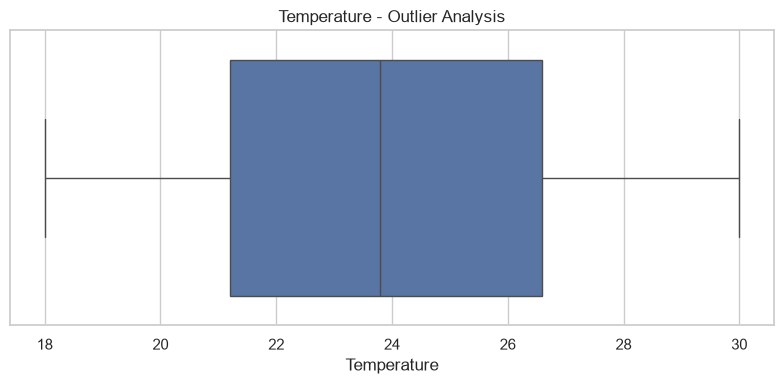

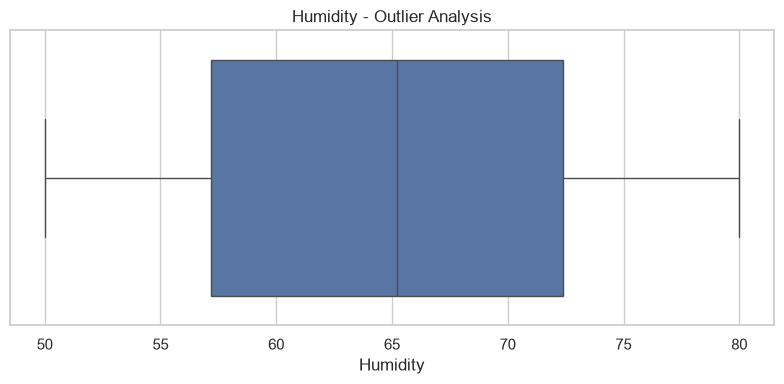

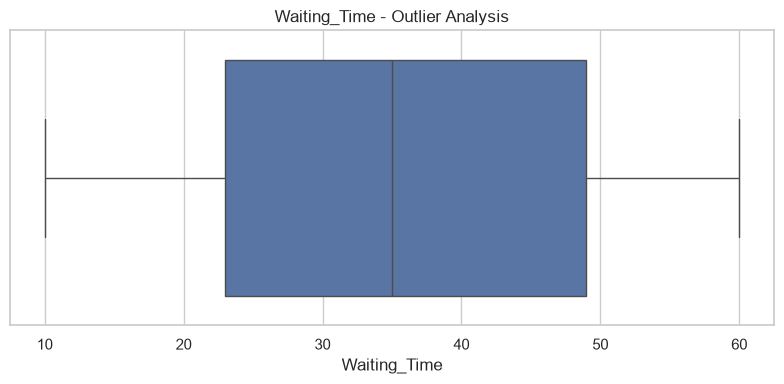

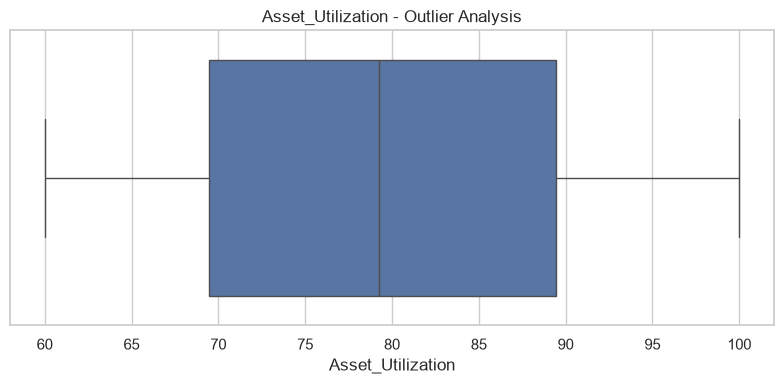

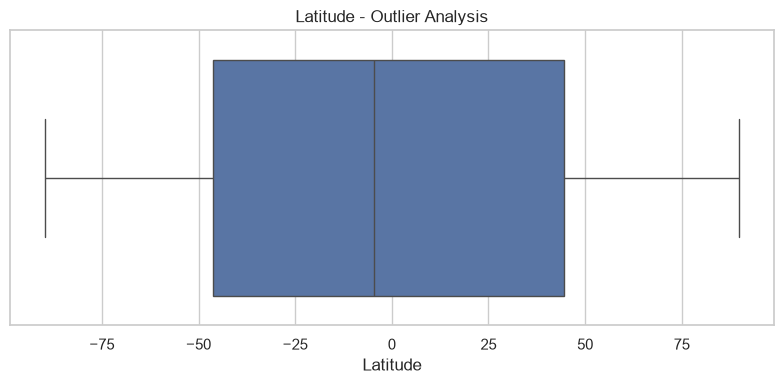

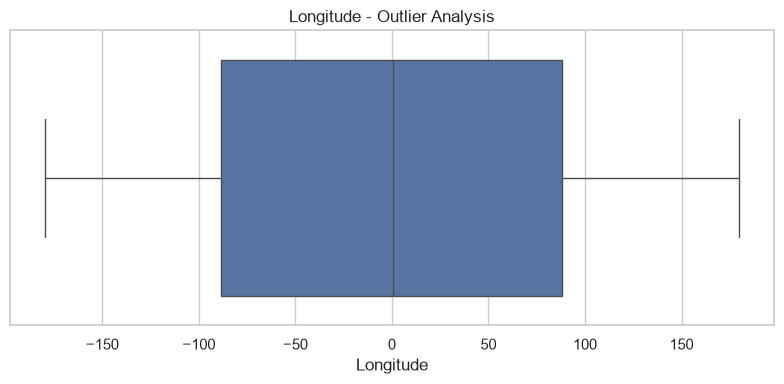

In [56]:
for column in smart_numeric_columns:
    plt.figure(figsize=(8, 4))

    sns.boxplot(
        x=smart[column]
    )

    plt.title(f"{column} - Outlier Analysis")
    plt.xlabel(column)

    plt.tight_layout()
    plt.show()

In [62]:
# Does traffic relate to delay?
smart.groupby(
    "Traffic_Status"
)["Logistics_Delay"].mean().sort_values(
    ascending=False
)

Traffic_Status
Heavy     1.00000
Detour    0.35942
Clear     0.35061
Name: Logistics_Delay, dtype: float64

In [63]:
# Does waiting time relate to delay?
smart.groupby(
    "Logistics_Delay"
)["Waiting_Time"].mean()

Logistics_Delay
0    36.103687
1    34.263251
Name: Waiting_Time, dtype: float64

In [64]:
# Does asset utilization relate to delay?
smart.groupby(
    "Logistics_Delay"
)["Asset_Utilization"].mean()

Logistics_Delay
0    79.640783
1    79.567138
Name: Asset_Utilization, dtype: float64

In [65]:
# Which delay reasons are most common?
smart["Logistics_Delay_Reason"].value_counts()

Logistics_Delay_Reason
Weather               267
Traffic               236
Mechanical Failure    234
Name: count, dtype: int64

In [66]:
# Does delay vary over time?
smart.groupby(
    smart["EDA_Timestamp"].dt.hour
)["Logistics_Delay"].mean()

EDA_Timestamp
0     0.531915
1     0.542857
2     0.512821
3     0.558140
4     0.651163
5     0.454545
6     0.583333
7     0.500000
8     0.640000
9     0.477273
10    0.534483
11    0.547619
12    0.600000
13    0.562500
14    0.674419
15    0.625000
16    0.550000
17    0.694444
18    0.454545
19    0.617647
20    0.605263
21    0.608696
22    0.437500
23    0.625000
Name: Logistics_Delay, dtype: float64

In [67]:
# Hourly delay pattern
hourly_delay = (
    smart.groupby(
        smart["EDA_Timestamp"].dt.hour
    )["Logistics_Delay"]
    .mean()
)

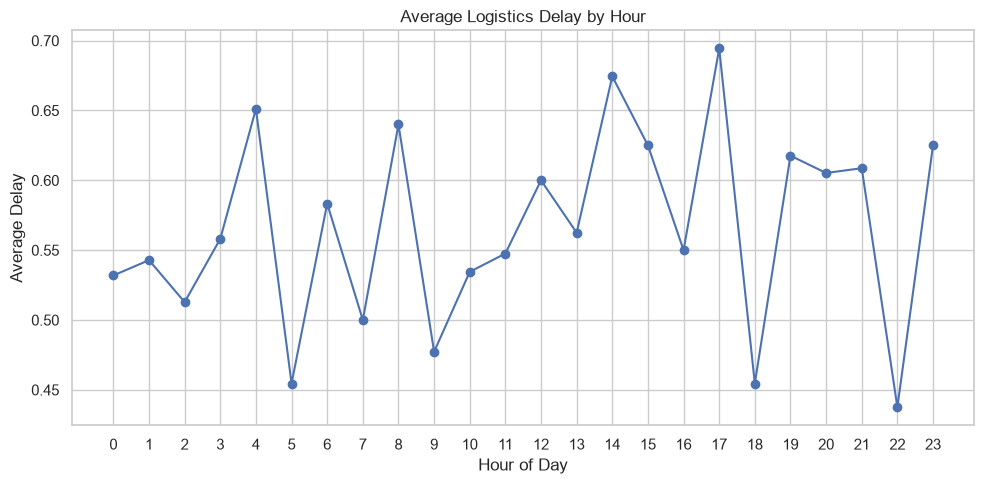

In [69]:
plt.figure(figsize=(10, 5))

hourly_delay.plot(
    marker="o"
)

plt.title("Average Logistics Delay by Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Average Delay")

plt.xticks(range(24))

plt.tight_layout()
plt.show()

In [70]:
# Day-of-week analysis
smart["EDA_DayOfWeek"] = (
    smart["EDA_Timestamp"].dt.day_name()
)

In [71]:
day_order = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday"
]

day_delay = (
    smart.groupby("EDA_DayOfWeek")["Logistics_Delay"]
    .mean()
    .reindex(day_order)
)

day_delay

EDA_DayOfWeek
Monday       0.522876
Tuesday      0.650000
Wednesday    0.563291
Thursday     0.555556
Friday       0.537415
Saturday     0.597122
Sunday       0.539062
Name: Logistics_Delay, dtype: float64

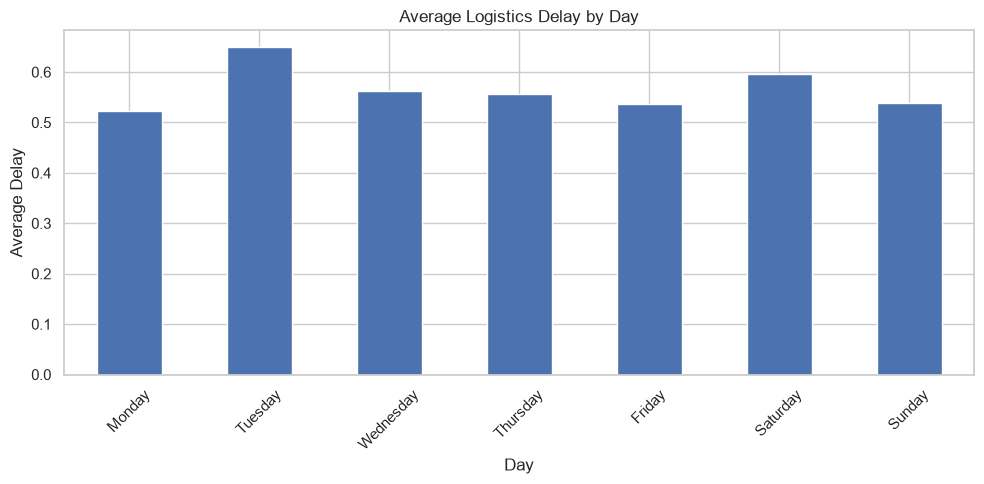

In [72]:
plt.figure(figsize=(10, 5))

day_delay.plot(kind="bar")

plt.title("Average Logistics Delay by Day")
plt.xlabel("Day")
plt.ylabel("Average Delay")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()